In [5]:
# Core NLP & Segmentation
!pip install wtpsplit
!pip install sentence-transformers
!pip install bertopic
!pip install umap-learn
!pip install hdbscan

# Graph
!pip install networkx
!pip install python-louvain  # community detection

# NLP Utilities
!pip install spacy
!pip install keybert
!pip install neuralcoref fastcoref # coreference resolution
!python -m spacy download en_core_web_sm

# Evaluation
!pip install rouge-score
!pip install bert-score

# Summarization Models
!pip install transformers
!pip install torch

# Utilities
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install tqdm

# ── Install datasets library ──────────────────────────────────
!pip install datasets

  Using cached neuralcoref-4.0.tar.gz (368 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 42.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
# ── Standard Library ──────────────────────────────────────────
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

# ── Core Scientific ───────────────────────────────────────────
import numpy as np
import pandas as pd
from tqdm import tqdm

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sentence Segmentation ─────────────────────────────────────
from wtpsplit import SaT                        # primary segmenter

# ── Embeddings ────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer

# ── Topic Modeling ────────────────────────────────────────────
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# ── Graph ─────────────────────────────────────────────────────
import networkx as nx
import community as community_louvain           # python-louvain

# ── NLP Utilities ─────────────────────────────────────────────
import spacy
from keybert import KeyBERT
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import jensenshannon

# ── Summarization ─────────────────────────────────────────────
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# ── Evaluation ────────────────────────────────────────────────
from rouge_score import rouge_scorer
from bert_score import score as bert_score

# ── Utility ───────────────────────────────────────────────────
from sklearn.preprocessing import normalize
from collections import defaultdict

from datasets import load_dataset

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
# ── Device Setup ──────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# ── Load Models ───────────────────────────────────────────────

# 1. Sentence segmenter (WtP SaT)
print("Loading SaT segmenter...")
sat = SaT("sat-3l")                             # lightweight & fast
# sat = SaT("sat-12l")                          # higher accuracy

# 2. Sentence embeddings
print("Loading SBERT...")
embedder = SentenceTransformer('all-MiniLM-L6-v2', device=device)
# embedder = SentenceTransformer('all-mpnet-base-v2')  # higher quality

# 3. spaCy for NER
print("Loading spaCy...")
nlp = spacy.load('en_core_web_sm')

# 4. KeyBERT for keyword extraction
print("Loading KeyBERT...")
kw_model = KeyBERT(model=embedder)

# 5. BERTopic components
print("Configuring BERTopic...")
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=3,                         # min sentences per topic
    min_samples=1,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    min_df=1,
    ngram_range=(1, 2)
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True
)

print("\n✓ All models loaded successfully")
print(f"  SaT        : sat-3l")
print(f"  Embedder   : all-MiniLM-L6-v2")
print(f"  spaCy      : en_core_web_sm")
print(f"  BERTopic   : configured with UMAP + HDBSCAN")

Using device: cpu
Loading SaT segmenter...


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


Loading SBERT...
Loading spaCy...
Loading KeyBERT...
Configuring BERTopic...

✓ All models loaded successfully
  SaT        : sat-3l
  Embedder   : all-MiniLM-L6-v2
  spaCy      : en_core_web_sm
  BERTopic   : configured with UMAP + HDBSCAN


In [3]:
# ── Pipeline Hyperparameters ──────────────────────────────────
CONFIG = {
    # Graph construction
    "edge_alpha"          : 0.5,    # semantic similarity weight
    "edge_beta"           : 0.3,    # topic similarity weight
    "edge_gamma"          : 0.2,    # entity overlap weight
    "edge_threshold"      : 0.3,    # minimum edge weight to keep
    "top_k_neighbors"     : 7,      # max edges per node

    # PageRank
    "damping_factor"      : 0.85,
    "pagerank_tol"        : 1e-6,
    "pagerank_max_iter"   : 200,

    # Scoring
    "lambda_global"       : 0.5,    # global pagerank weight
    "lambda_local"        : 0.3,    # local centrality weight
    "lambda_between"      : 0.2,    # betweenness weight

    # Selection
    "mmr_lambda"          : 0.7,    # relevance vs diversity tradeoff
    "summary_sentences"   : 10,     # total sentences in summary
    "bridge_sentences"    : 2,      # cross-topic bridge sentences

    # Generation
    "max_summary_tokens"  : 512,
}

print("✓ CONFIG loaded")
print(json.dumps(CONFIG, indent=2))

✓ CONFIG loaded
{
  "edge_alpha": 0.5,
  "edge_beta": 0.3,
  "edge_gamma": 0.2,
  "edge_threshold": 0.3,
  "top_k_neighbors": 7,
  "damping_factor": 0.85,
  "pagerank_tol": 1e-06,
  "pagerank_max_iter": 200,
  "lambda_global": 0.5,
  "lambda_local": 0.3,
  "lambda_between": 0.2,
  "mmr_lambda": 0.7,
  "summary_sentences": 10,
  "bridge_sentences": 2,
  "max_summary_tokens": 512
}


In [4]:
print("Loading CNN/DailyMail...")
dataset = load_dataset("cnn_dailymail", "3.0.0")

# take exactly one sample from test split
raw_sample = dataset['test'][0]

print("\n✓ Sample loaded")
print("=" * 65)
print("ARTICLE (first 600 chars):")
print("-" * 65)
print(raw_sample['article'][:600], "...")
print("\n" + "=" * 65)
print("REFERENCE SUMMARY:")
print("-" * 65)
print(raw_sample['highlights'])
print("=" * 65)
print(f"\nArticle word count  : {len(raw_sample['article'].split())}")
print(f"Summary word count  : {len(raw_sample['highlights'].split())}")
print(f"Article ID          : {raw_sample['id']}")

Loading CNN/DailyMail...

✓ Sample loaded
ARTICLE (first 600 chars):
-----------------------------------------------------------------
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination i ...

REFERENCE SUMMARY:
-----------------------------------------------------------------
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could op

In [5]:
def clean_text(text: str) -> str:
    text = re.sub(r'^[A-Z\s,]+\([A-Za-z]+\)\s*--\s*', '', text)
    text = re.sub(r'\(CNN\)\s*', '', text)
    text = text.replace('\u2019', "'").replace('\u2018', "'")
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)
    return text.strip()


def segment_sentences(text: str, sat_model) -> list:
    sentences = sat_model.split(text)
    sentences = [s.strip() for s in sentences
                 if len(s.strip().split()) >= 5]
    return sentences


def extract_entities(sentence: str, spacy_model) -> set:
    doc = spacy_model(sentence)
    return set(ent.text.lower().strip() for ent in doc.ents)


def preprocess_single(raw: dict, sat_model, spacy_model) -> dict:
    clean   = clean_text(raw['article'])
    sents   = segment_sentences(clean, sat_model)

    sentence_data = []
    for idx, sent in enumerate(sents):
        sentence_data.append({
            "sent_id"         : idx,
            "text"            : sent,
            "position_weight" : round(1.0 / np.log1p(idx + 1), 4),
            "entities"        : extract_entities(sent, spacy_model),
        })

    return {
        "article_id" : raw['id'],
        "clean_text" : clean,
        "sentences"  : sentence_data,
        "n_sentences": len(sentence_data),
        "reference"  : raw['highlights'],
    }

In [6]:
print("Preprocessing single article...\n")

article = preprocess_single(
    raw        = raw_sample,
    sat_model  = sat,
    spacy_model= nlp,
)
article

Preprocessing single article...



{'article_id': 'f001ec5c4704938247d27a44948eebb37ae98d01',
 'clean_text': 'The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC\'s founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. As members of the court, Palestinians may be subject to counter-charges as well. Israel and the United States, neither of which is an ICC member, opposed the Palestinians\' efforts to join the body. But Palestin

## Step 2: SBERT Embedding + BERTopic Topic Modeling

### Encode All Sentences with SBERT

In [7]:
# ── Extract sentence texts ─────────────────────────────────────
sentences     = article['sentences']
sentence_texts = [s['text'] for s in sentences]

print(f"Encoding {len(sentence_texts)} sentences with SBERT...")
print("-" * 65)

# ── Batch encode ───────────────────────────────────────────────
embeddings = embedder.encode(
    sentence_texts,
    batch_size         = 32,
    show_progress_bar  = True,
    convert_to_numpy   = True,
    normalize_embeddings = True     # L2 normalize → cosine sim = dot product
)

print(f"\n✓ Embeddings computed")
print(f"  Shape         : {embeddings.shape}")
print(f"  Dtype         : {embeddings.dtype}")
print(f"  Norm (S0)     : {np.linalg.norm(embeddings[0]):.4f}")  # should be ~1.0

Encoding 27 sentences with SBERT...
-----------------------------------------------------------------


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Embeddings computed
  Shape         : (27, 384)
  Dtype         : float32
  Norm (S0)     : 1.0000


Verify Embedding Quality — Quick Sanity Check

In [8]:
# ── Spot check: most similar sentence to S0 ───────────────────
ref_idx  = 0
ref_sent = sentence_texts[ref_idx]

# cosine similarity of S0 against all others
sims = cosine_similarity([embeddings[ref_idx]], embeddings)[0]
sims[ref_idx] = -1                              # exclude self

top5_idx = np.argsort(sims)[::-1][:5]

print(f"Reference sentence [S{ref_idx}]:")
print(f"  \"{ref_sent[:100]}\"")
print(f"\nTop 5 most semantically similar sentences:")
print("-" * 65)
for rank, idx in enumerate(top5_idx, 1):
    print(f"  [{rank}] S{idx:02d} (sim={sims[idx]:.4f})")
    print(f"       \"{sentence_texts[idx][:100]}\"")
    print()

Reference sentence [S0]:
  "The Palestinian Authority officially became the 123rd member of the International Criminal Court on "

Top 5 most semantically similar sentences:
-----------------------------------------------------------------
  [1] S04 (sim=0.5976)
       "As members of the court, Palestinians may be subject to counter-charges as well."

  [2] S02 (sim=0.5435)
       "The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its juri"

  [3] S17 (sim=0.5167)
       ""As we have said repeatedly, we do not believe that Palestine is a state and therefore we do not bel"

  [4] S03 (sim=0.5094)
       "Later that month, the ICC opened a preliminary examination into the situation in Palestinian territo"

  [5] S25 (sim=0.4975)
       "The International Criminal Court was set up in 2002 to prosecute genocide, crimes against humanity a"



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Compute Full Pairwise Cosine Similarity Matrix

✓ Semantic similarity matrix computed
  Shape  : (27, 27)
  Min    : -0.1263
  Max    : 1.0000  (diagonal = 1.0)
  Mean   : 0.3128


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


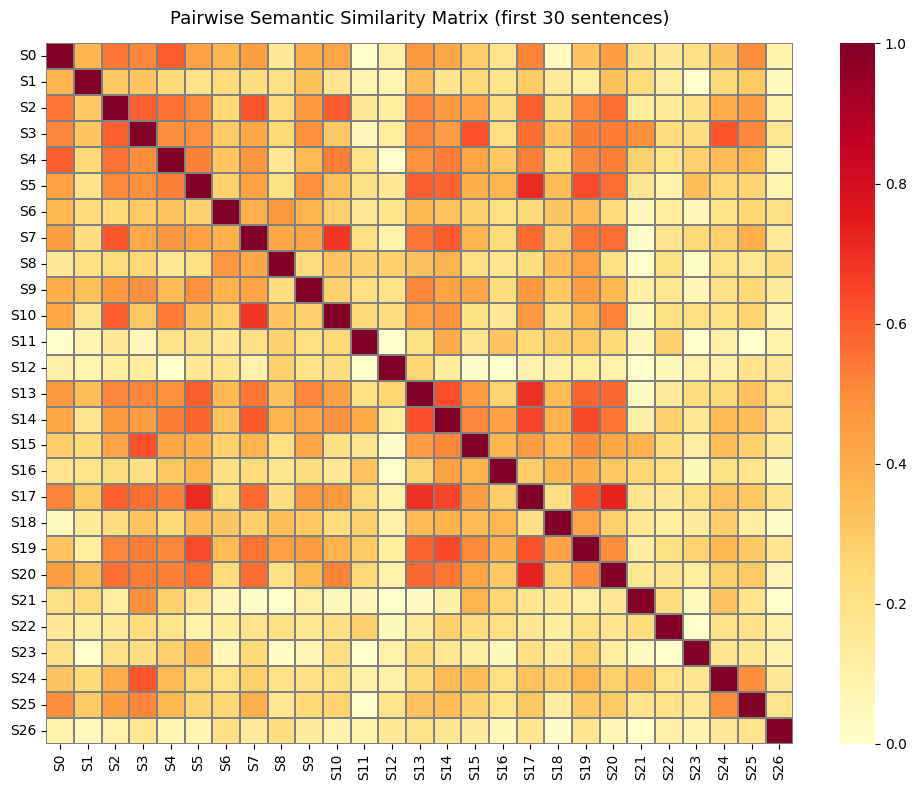

In [9]:
# ── Pairwise cosine similarity matrix (n × n) ─────────────────
# Since embeddings are L2-normalized: cosine_sim = dot product
semantic_sim_matrix = embeddings @ embeddings.T

print(f"✓ Semantic similarity matrix computed")
print(f"  Shape  : {semantic_sim_matrix.shape}")
print(f"  Min    : {semantic_sim_matrix.min():.4f}")
print(f"  Max    : {semantic_sim_matrix.max():.4f}  (diagonal = 1.0)")
print(f"  Mean   : {semantic_sim_matrix.mean():.4f}")

# ── Visualize similarity heatmap ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
n = min(30, len(sentences))                     # show first 30 sentences

sns.heatmap(
    semantic_sim_matrix[:n, :n],
    ax       = ax,
    cmap     = 'YlOrRd',
    vmin     = 0, vmax = 1,
    xticklabels = [f"S{i}" for i in range(n)],
    yticklabels = [f"S{i}" for i in range(n)],
    linewidths  = 0.3,
    linecolor   = 'gray'
)
ax.set_title("Pairwise Semantic Similarity Matrix (first 30 sentences)",
             fontsize=13, pad=14)
plt.tight_layout()
plt.show()

### Run BERTopic on Sentence Embeddings

In [10]:
print("Fitting BERTopic on sentence embeddings...")
print(f"  Input: {len(sentence_texts)} sentences\n")

# ── Fit BERTopic ───────────────────────────────────────────────
# Pass precomputed embeddings directly — avoids re-encoding
topic_assignments, topic_probs = topic_model.fit_transform(
    sentence_texts,
    embeddings = embeddings
)

# ── Results ───────────────────────────────────────────────────
unique_topics = sorted(set(topic_assignments))
n_topics      = len([t for t in unique_topics if t != -1])

print(f"✓ BERTopic fitting complete")
print(f"  Total topics found    : {n_topics}")
print(f"  Outlier sentences (-1): {sum(1 for t in topic_assignments if t == -1)}")
print(f"  Topic IDs             : {unique_topics}")

2026-03-19 08:27:29,664 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic on sentence embeddings...
  Input: 27 sentences



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-03-19 08:27:40,964 - BERTopic - Dimensionality - Completed ✓
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-03-19 08:27:40,966 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-19 08:27:40,983 - BERTopic - Cluster - Completed ✓
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled 

✓ BERTopic fitting complete
  Total topics found    : 5
  Outlier sentences (-1): 1
  Topic IDs             : [-1, 0, 1, 2, 3, 4]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Inspect Topic Keywords

In [11]:
# ── Topic info ────────────────────────────────────────────────
topic_info = topic_model.get_topic_info()
print("\nTopic Summary:")
print("-" * 65)
print(topic_info[['Topic', 'Count', 'Name']].to_string(index=False))

print("\n\nTop keywords per topic:")
print("-" * 65)
for tid in unique_topics:
    if tid == -1:
        continue
    keywords = topic_model.get_topic(tid)
    kw_str   = " | ".join([f"{w}({round(s,3)})" for w, s in keywords[:6]])
    print(f"  Topic {tid:02d} : {kw_str}")


Topic Summary:
-----------------------------------------------------------------
 Topic  Count                                                         Name
    -1      1 -1_benjamin_benjamin netanyahu_boundaries_court overstepping
     0      8                           0_israel_said_states_united states
     1      6                                1_crimes_court_war crimes_war
     2      4                        2_statute_rome statute_rome_palestine
     3      4                       3_rights_justice_almalki_brings closer
     4      4                                   4_icc_said_palestine_state


Top keywords per topic:
-----------------------------------------------------------------
  Topic 00 : israel(0.076) | said(0.069) | states(0.056) | united states(0.056) | united(0.056) | decision(0.056)
  Topic 01 : crimes(0.103) | court(0.098) | war crimes(0.076) | war(0.07) | palestinian(0.065) | formal(0.056)
  Topic 02 : statute(0.109) | rome statute(0.088) | rome(0.088) | palestine(

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Build Topic Distribution Matrix θ

In [12]:
  # ── Build θ matrix: (n_sentences × n_topics) ──────────────────
# θᵢ = soft topic distribution for sentence i
# BERTopic gives hard assignments — we build a soft version
# using approximate_distribution for richer edge weights

print("\nComputing soft topic distributions (approximate)...")

# Method 1: use approximate_distribution (BERTopic built-in)
try:
    topic_distr, _ = topic_model.approximate_distribution(
        sentence_texts,
        window         = 4,
        stride         = 1,
        use_embedding_model = True
    )
    print(f"  ✓ Soft distributions via approximate_distribution")
    print(f"  Shape: {topic_distr.shape}")

except Exception as e:
    print(f"  approximate_distribution unavailable: {e}")
    print(f"  Falling back to one-hot hard assignments...")

    # Method 2: fallback — one-hot from hard topic_assignments
    n_sents   = len(sentence_texts)
    valid_topics = [t for t in unique_topics if t != -1]
    n_t       = len(valid_topics)
    topic_map = {tid: idx for idx, tid in enumerate(valid_topics)}

    topic_distr = np.zeros((n_sents, n_t), dtype=np.float32)
    for i, tid in enumerate(topic_assignments):
        if tid != -1:
            topic_distr[i, topic_map[tid]] = 1.0
        else:
            # outlier (-1): uniform distribution
            topic_distr[i, :] = 1.0 / n_t

    print(f"  ✓ Fallback one-hot distributions built")
    print(f"  Shape: {topic_distr.shape}")

# ── Add small epsilon to avoid log(0) in JS divergence ────────
epsilon    = 1e-8
theta      = topic_distr + epsilon
theta      = theta / theta.sum(axis=1, keepdims=True)  # re-normalize rows

print(f"\n✓ θ matrix ready")
print(f"  Shape        : {theta.shape}")
print(f"  Row sum check: {theta[0].sum():.6f}  (should be 1.0)")


Computing soft topic distributions (approximate)...


  0%|          | 0/1 [00:00<?, ?it/s]

  approximate_distribution unavailable: 'NoneType' object has no attribute 'embed_documents'
  Falling back to one-hot hard assignments...
  ✓ Fallback one-hot distributions built
  Shape: (27, 5)

✓ θ matrix ready
  Shape        : (27, 5)
  Row sum check: 1.000000  (should be 1.0)


### Compute Pairwise Topic Similarity Matrix

Computing pairwise topic similarity matrix...
✓ Topic similarity matrix computed
  Shape  : (27, 27)
  Min    : 0.0000
  Max    : 1.0000
  Mean   : 0.2200


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


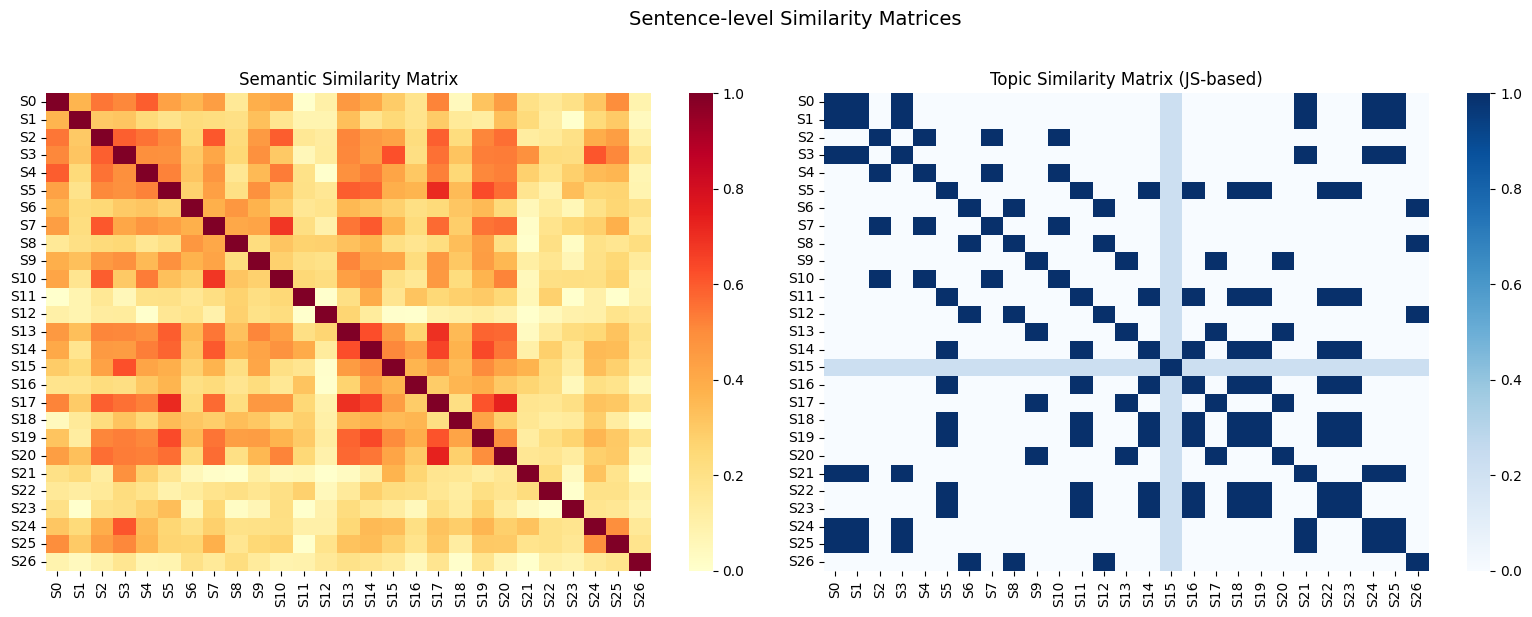

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
# ── JS divergence → topic similarity for all pairs ────────────
print("Computing pairwise topic similarity matrix...")

n_sents          = len(sentences)
topic_sim_matrix = np.zeros((n_sents, n_sents), dtype=np.float32)

for i in range(n_sents):
    for j in range(i, n_sents):
        if i == j:
            topic_sim_matrix[i][j] = 1.0
            continue

        # JS divergence ∈ [0, 1] (base-2 log version)
        js_div = jensenshannon(theta[i], theta[j], base=2.0)

        # convert to similarity
        sim    = 1.0 - float(js_div)
        topic_sim_matrix[i][j] = sim
        topic_sim_matrix[j][i] = sim

print(f"✓ Topic similarity matrix computed")
print(f"  Shape  : {topic_sim_matrix.shape}")
print(f"  Min    : {topic_sim_matrix.min():.4f}")
print(f"  Max    : {topic_sim_matrix.max():.4f}")
print(f"  Mean   : {topic_sim_matrix.mean():.4f}")

# ── Visualize ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
n         = min(30, n_sents)

sns.heatmap(semantic_sim_matrix[:n, :n],
            ax=axes[0], cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=[f"S{i}" for i in range(n)],
            yticklabels=[f"S{i}" for i in range(n)])
axes[0].set_title("Semantic Similarity Matrix", fontsize=12)

sns.heatmap(topic_sim_matrix[:n, :n],
            ax=axes[1], cmap='Blues', vmin=0, vmax=1,
            xticklabels=[f"S{i}" for i in range(n)],
            yticklabels=[f"S{i}" for i in range(n)])
axes[1].set_title("Topic Similarity Matrix (JS-based)", fontsize=12)

plt.suptitle("Sentence-level Similarity Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Attach Topic Assignments Back to Sentences

In [14]:
# ── Store everything back into article['sentences'] ───────────
for i, sent in enumerate(article['sentences']):
    sent['embedding']         = embeddings[i]
    sent['topic_id']          = int(topic_assignments[i])
    sent['topic_distribution']= theta[i]

# ── Store matrices at article level ───────────────────────────
article['embeddings']         = embeddings
article['theta']              = theta
article['semantic_sim_matrix']= semantic_sim_matrix
article['topic_sim_matrix']   = topic_sim_matrix
article['topic_assignments']  = topic_assignments
article['n_topics']           = n_topics
article['unique_topics']      = unique_topics

print("✓ All representations attached to article object")
print(f"\nPer-sentence data now contains:")
print(f"  sent_id           → int")
print(f"  text              → str")
print(f"  position_weight   → float")
print(f"  entities          → set")
print(f"  embedding         → np.array ({embeddings.shape[1]}d)")
print(f"  topic_id          → int (BERTopic hard assignment)")
print(f"  topic_distribution→ np.array ({theta.shape[1]}d soft θ)")

✓ All representations attached to article object

Per-sentence data now contains:
  sent_id           → int
  text              → str
  position_weight   → float
  entities          → set
  embedding         → np.array (384d)
  topic_id          → int (BERTopic hard assignment)
  topic_distribution→ np.array (5d soft θ)


### Per-Topic Sentence Distribution

In [15]:
# ── Show which sentences belong to which topic ────────────────
print("\nSentence distribution across topics:")
print("-" * 65)

topic_to_sents = defaultdict(list)
for s in article['sentences']:
    topic_to_sents[s['topic_id']].append(s['sent_id'])

for tid in sorted(topic_to_sents.keys()):
    sent_ids  = topic_to_sents[tid]
    label     = "OUTLIER" if tid == -1 else f"Topic {tid:02d}"
    kw_str    = ""
    if tid != -1:
        kws    = topic_model.get_topic(tid)
        kw_str = " | ".join([w for w, _ in kws[:4]])

    print(f"\n  [{label}]  ({len(sent_ids)} sentences)  keywords: {kw_str}")
    for sid in sent_ids[:3]:                    # show first 3
        print(f"    S{sid:02d}: {sentence_texts[sid][:90]}...")
    if len(sent_ids) > 3:
        print(f"    ... and {len(sent_ids)-3} more")

print("\n" + "=" * 65)
print(f"✓ Step 2 complete. Ready for graph construction.")
print(f"  Sentences     : {n_sents}")
print(f"  Topics found  : {n_topics}")
print(f"  θ shape       : {theta.shape}")
print(f"  Semantic matrix: {semantic_sim_matrix.shape}")
print(f"  Topic matrix  : {topic_sim_matrix.shape}")


Sentence distribution across topics:
-----------------------------------------------------------------

  [OUTLIER]  (1 sentences)  keywords: 
    S15: In January, when the preliminary ICC examination was opened, Israeli Prime Minister Benjam...

  [Topic 00]  (8 sentences)  keywords: israel | said | states | united states
    S05: Israel and the United States, neither of which is an ICC member, opposed the Palestinians'...
    S11: These are substantive commitments, which cannot be taken lightly," she said....
    S14: "What's objectionable is the attempts to undermine international justice, not Palestine's ...
    ... and 5 more

  [Topic 01]  (6 sentences)  keywords: crimes | court | war crimes | war
    S00: The Palestinian Authority officially became the 123rd member of the International Criminal...
    S01: The formal accession was marked with a ceremony at The Hague, in the Netherlands, where th...
    S03: Later that month, the ICC opened a preliminary examination into the sit

## Step 3: Entity Overlap Matrix + Graph Construction

### Compute Pairwise Entity Overlap Matrix

In [16]:
# ── Jaccard similarity between entity sets ────────────────────
print("Computing pairwise entity overlap matrix...")

n_sents             = article['n_sentences']
entity_sim_matrix   = np.zeros((n_sents, n_sents), dtype=np.float32)

for i in range(n_sents):
    for j in range(i, n_sents):
        if i == j:
            entity_sim_matrix[i][j] = 1.0
            continue

        ei = article['sentences'][i]['entities']
        ej = article['sentences'][j]['entities']

        # if both sentences have no entities → 0 overlap
        if len(ei) == 0 and len(ej) == 0:
            entity_sim_matrix[i][j] = 0.0
            entity_sim_matrix[j][i] = 0.0
            continue

        # Jaccard = |intersection| / |union|
        intersection = len(ei & ej)
        union        = len(ei | ej)
        jaccard      = intersection / union if union > 0 else 0.0

        entity_sim_matrix[i][j] = jaccard
        entity_sim_matrix[j][i] = jaccard

print(f"✓ Entity overlap matrix computed")
print(f"  Shape        : {entity_sim_matrix.shape}")
print(f"  Non-zero     : {np.count_nonzero(entity_sim_matrix)} pairs")
print(f"  Mean (off-diag): {entity_sim_matrix[entity_sim_matrix < 1.0].mean():.4f}")

# store at article level
article['entity_sim_matrix'] = entity_sim_matrix

Computing pairwise entity overlap matrix...
✓ Entity overlap matrix computed
  Shape        : (27, 27)
  Non-zero     : 127 pairs
  Mean (off-diag): 0.0310


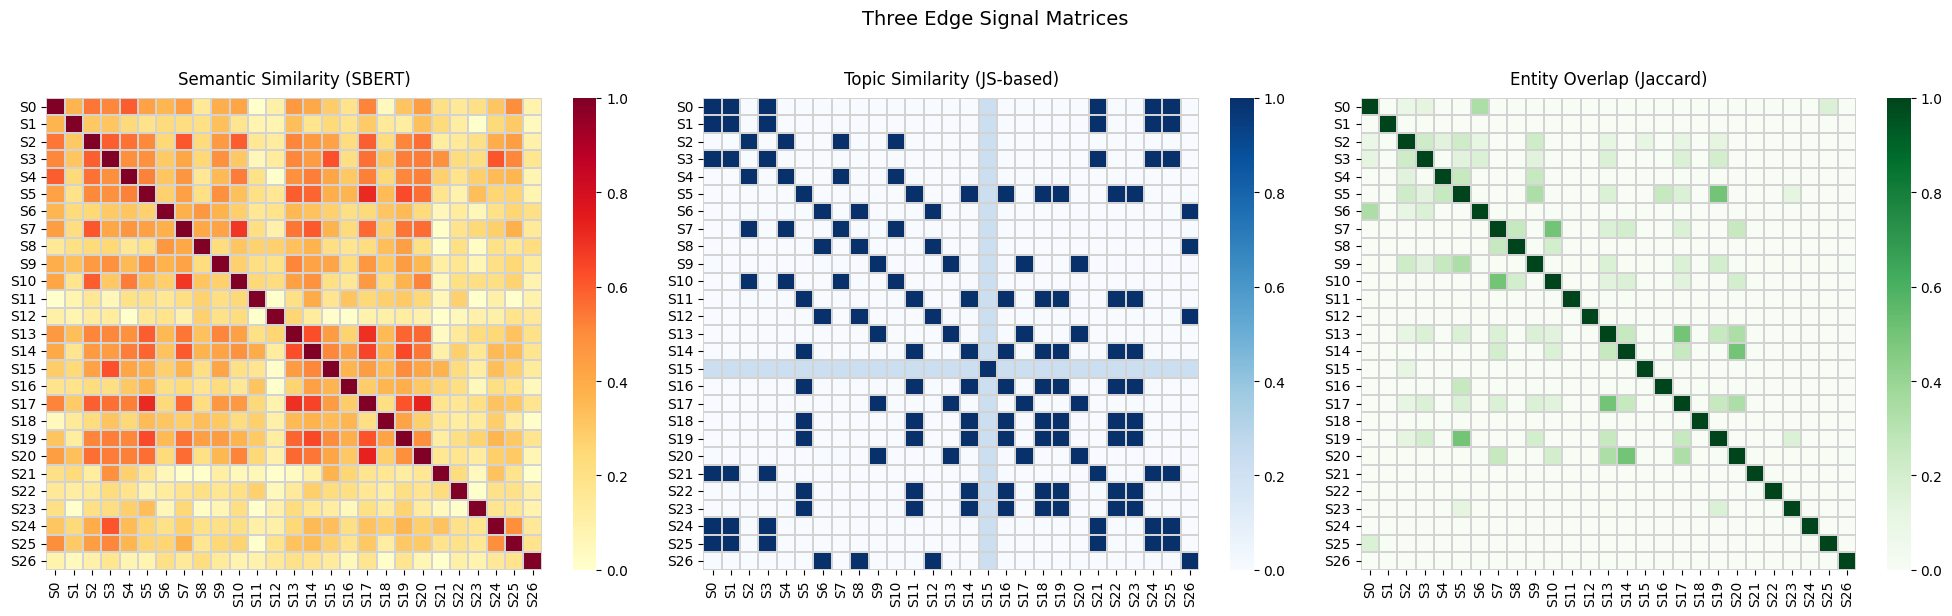

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
n         = min(30, n_sents)
cmap_list = ['YlOrRd', 'Blues', 'Greens']
titles    = [
    "Semantic Similarity (SBERT)",
    "Topic Similarity (JS-based)",
    "Entity Overlap (Jaccard)"
]
matrices  = [
    article['semantic_sim_matrix'],
    article['topic_sim_matrix'],
    article['entity_sim_matrix']
]

for ax, mat, title, cmap in zip(axes, matrices, titles, cmap_list):
    sns.heatmap(
        mat[:n, :n],
        ax          = ax,
        cmap        = cmap,
        vmin        = 0, vmax = 1,
        xticklabels = [f"S{i}" for i in range(n)],
        yticklabels = [f"S{i}" for i in range(n)],
        linewidths  = 0.2,
        linecolor   = 'lightgray'
    )
    ax.set_title(title, fontsize=12, pad=10)

plt.suptitle("Three Edge Signal Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Compute Combined Edge Weight Matrix

In [18]:
# ── Weighted fusion of all three signals ──────────────────────
alpha = CONFIG['edge_alpha']            # 0.5 semantic
beta  = CONFIG['edge_beta']             # 0.3 topic
gamma = CONFIG['edge_gamma']            # 0.2 entity

print(f"Computing combined edge weight matrix...")
print(f"  α (semantic) = {alpha}")
print(f"  β (topic)    = {beta}")
print(f"  γ (entity)   = {gamma}")
print(f"  α+β+γ        = {alpha+beta+gamma}")

edge_weight_matrix = (
      alpha * article['semantic_sim_matrix']
    + beta  * article['topic_sim_matrix']
    + gamma * article['entity_sim_matrix']
)

# diagonal = self-similarity → set to 0 (no self-loops)
np.fill_diagonal(edge_weight_matrix, 0.0)

print(f"\n✓ Edge weight matrix computed")
print(f"  Shape  : {edge_weight_matrix.shape}")
print(f"  Min    : {edge_weight_matrix.min():.4f}")
print(f"  Max    : {edge_weight_matrix.max():.4f}")
print(f"  Mean   : {edge_weight_matrix.mean():.4f}")

article['edge_weight_matrix'] = edge_weight_matrix

Computing combined edge weight matrix...
  α (semantic) = 0.5
  β (topic)    = 0.3
  γ (entity)   = 0.2
  α+β+γ        = 1.0

✓ Edge weight matrix computed
  Shape  : (27, 27)
  Min    : -0.0393
  Max    : 0.7495
  Mean   : 0.1987


### Analyze Edge Weight Distribution


Edge weight stats:
  Total pairs   : 351
  Above threshold (0.3): 80 (22.8%)


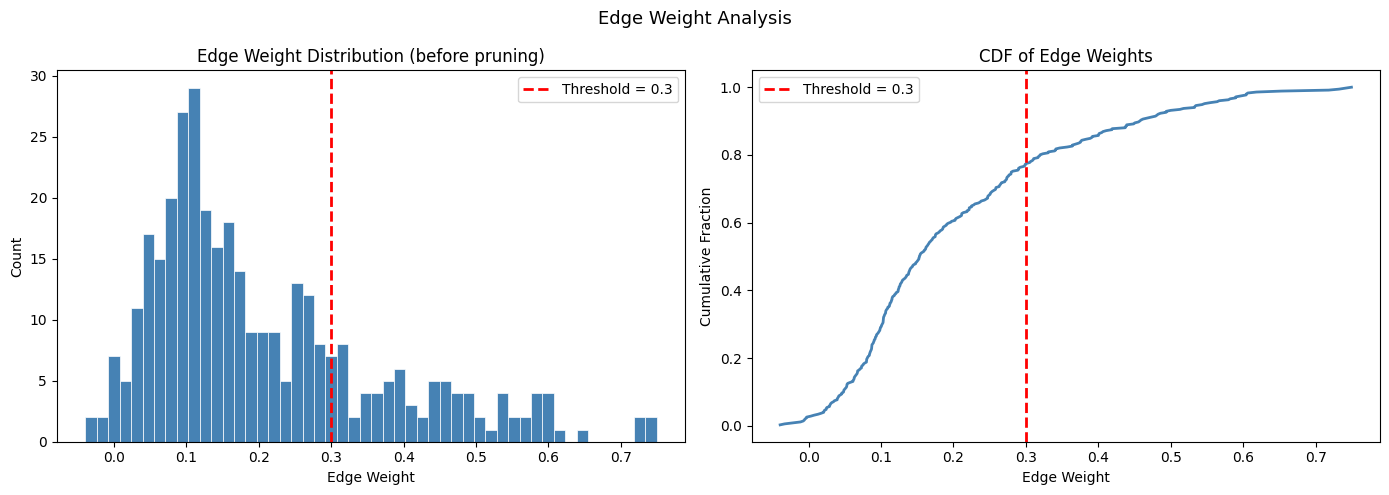

In [19]:
# ── Distribution of edge weights before pruning ───────────────
weights_flat = edge_weight_matrix[
    np.triu_indices(n_sents, k=1)          # upper triangle only
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(weights_flat, bins=50, color='steelblue',
             edgecolor='white', linewidth=0.5)
axes[0].axvline(CONFIG['edge_threshold'], color='red',
                linestyle='--', linewidth=2,
                label=f"Threshold = {CONFIG['edge_threshold']}")
axes[0].set_xlabel("Edge Weight")
axes[0].set_ylabel("Count")
axes[0].set_title("Edge Weight Distribution (before pruning)")
axes[0].legend()

# CDF
sorted_w = np.sort(weights_flat)
cdf      = np.arange(1, len(sorted_w)+1) / len(sorted_w)
axes[1].plot(sorted_w, cdf, color='steelblue', linewidth=2)
axes[1].axvline(CONFIG['edge_threshold'], color='red',
                linestyle='--', linewidth=2,
                label=f"Threshold = {CONFIG['edge_threshold']}")
axes[1].set_xlabel("Edge Weight")
axes[1].set_ylabel("Cumulative Fraction")
axes[1].set_title("CDF of Edge Weights")
axes[1].legend()

pct_kept = (weights_flat >= CONFIG['edge_threshold']).mean() * 100
print(f"\nEdge weight stats:")
print(f"  Total pairs   : {len(weights_flat):,}")
print(f"  Above threshold ({CONFIG['edge_threshold']}): "
      f"{(weights_flat >= CONFIG['edge_threshold']).sum():,} "
      f"({pct_kept:.1f}%)")

plt.suptitle("Edge Weight Analysis", fontsize=13)
plt.tight_layout()
plt.show()

### Build the Graph

In [20]:
def build_graph(
    sentences,
    edge_weight_matrix,
    threshold   = 0.3,
    top_k       = 7,
) -> nx.Graph:
    """
    Build a weighted undirected graph from sentences.

    Rules:
      1. Create an edge only if weight >= threshold
      2. Per node, keep only top-K strongest edges
      3. Store all three sub-scores as edge attributes
    """
    n     = len(sentences)
    G     = nx.Graph()

    # ── Add nodes ─────────────────────────────────────────────
    for s in sentences:
        G.add_node(
            s['sent_id'],
            text             = s['text'],
            topic_id         = s['topic_id'],
            position_weight  = s['position_weight'],
            entities         = s['entities'],
        )

    # ── Collect candidate edges per node (top-K) ──────────────
    # For each node i, find top-K neighbors by weight
    node_edges = defaultdict(list)             # node → [(weight, j)]

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            w = edge_weight_matrix[i][j]
            if w >= threshold:
                node_edges[i].append((w, j))

        # keep top-K neighbors for node i
        node_edges[i] = sorted(
            node_edges[i], key=lambda x: x[0], reverse=True
        )[:top_k]

    # ── Add edges (undirected → add once per pair) ─────────────
    added_edges = set()

    for i, neighbors in node_edges.items():
        for w, j in neighbors:
            pair = (min(i,j), max(i,j))
            if pair in added_edges:
                continue

            # check j also has i in its top-K (mutual constraint)
            # optional: comment out for denser graph
            j_neighbors = [nb for _, nb in node_edges[j]]
            if i not in j_neighbors:
                continue

            G.add_edge(
                i, j,
                weight          = float(w),
                semantic_sim    = float(article['semantic_sim_matrix'][i][j]),
                topic_sim       = float(article['topic_sim_matrix'][i][j]),
                entity_overlap  = float(article['entity_sim_matrix'][i][j]),
            )
            added_edges.add(pair)

    return G


# ── Build graph ───────────────────────────────────────────────
print("Building graph...")

G = build_graph(
    sentences          = article['sentences'],
    edge_weight_matrix = edge_weight_matrix,
    threshold          = CONFIG['edge_threshold'],
    top_k              = CONFIG['top_k_neighbors'],
)

article['graph'] = G

print(f"\n✓ Graph built")
print(f"  Nodes          : {G.number_of_nodes()}")
print(f"  Edges          : {G.number_of_edges()}")
print(f"  Density        : {nx.density(G):.4f}")
print(f"  Avg degree     : {np.mean([d for _, d in G.degree()]):.2f}")
print(f"  Connected      : {nx.is_connected(G)}")
if not nx.is_connected(G):
    components = list(nx.connected_components(G))
    print(f"  Components     : {len(components)}")

Building graph...

✓ Graph built
  Nodes          : 27
  Edges          : 65
  Density        : 0.1852
  Avg degree     : 4.81
  Connected      : False
  Components     : 2


### Graph Statistics & Edge Attribute Summary

Graph Edge Attribute Summary:
-----------------------------------------------------------------
  Attribute                 Min     Mean      Max      Std
  ----------------------------------------------------
  weight                 0.3010   0.4836   0.7495   0.1069
  semantic_sim           0.0470   0.4002   0.7312   0.1692
  topic_sim              0.0000   0.8990   1.0000   0.2924
  entity_overlap         0.0000   0.0693   0.5000   0.1288


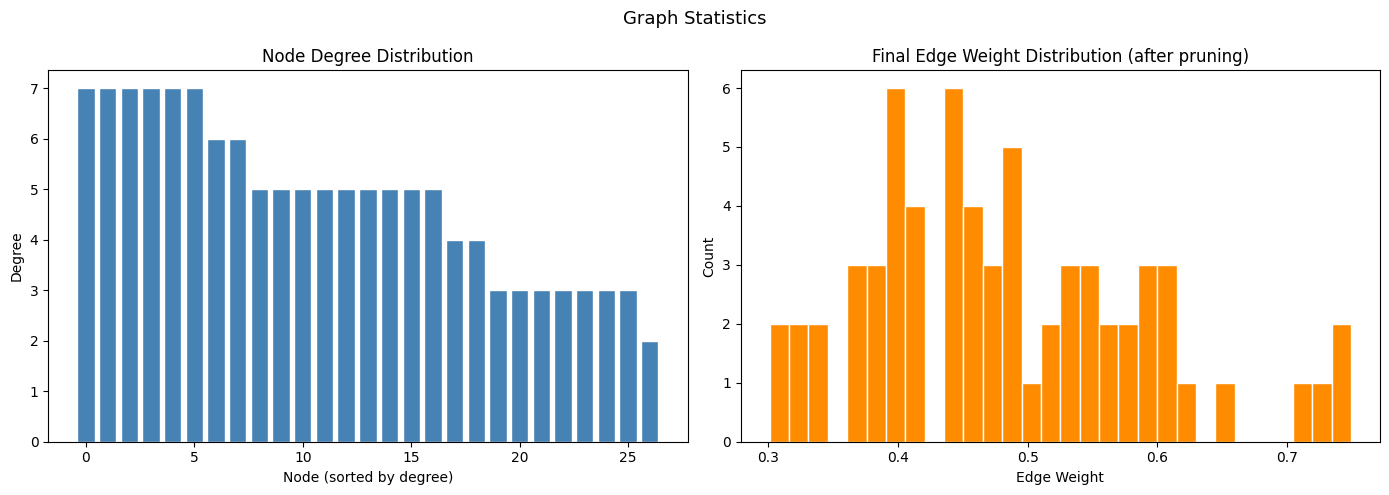

In [21]:
# ── Degree distribution ───────────────────────────────────────
degrees     = [d for _, d in G.degree()]
edge_weights= [d['weight'] for _, _, d in G.edges(data=True)]
sem_sims    = [d['semantic_sim'] for _, _, d in G.edges(data=True)]
top_sims    = [d['topic_sim'] for _, _, d in G.edges(data=True)]
ent_sims    = [d['entity_overlap'] for _, _, d in G.edges(data=True)]

print("Graph Edge Attribute Summary:")
print("-" * 65)
print(f"  {'Attribute':<20} {'Min':>8} {'Mean':>8} {'Max':>8} {'Std':>8}")
print(f"  {'-'*52}")
for name, vals in [
    ("weight",          edge_weights),
    ("semantic_sim",    sem_sims),
    ("topic_sim",       top_sims),
    ("entity_overlap",  ent_sims),
]:
    print(f"  {name:<20} {min(vals):>8.4f} {np.mean(vals):>8.4f} "
          f"{max(vals):>8.4f} {np.std(vals):>8.4f}")

# ── Plot degree distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(degrees)),
            sorted(degrees, reverse=True),
            color='steelblue', edgecolor='white')
axes[0].set_xlabel("Node (sorted by degree)")
axes[0].set_ylabel("Degree")
axes[0].set_title("Node Degree Distribution")

axes[1].hist(edge_weights, bins=30,
             color='darkorange', edgecolor='white')
axes[1].set_xlabel("Edge Weight")
axes[1].set_ylabel("Count")
axes[1].set_title("Final Edge Weight Distribution (after pruning)")

plt.suptitle("Graph Statistics", fontsize=13)
plt.tight_layout()
plt.show()

### Visualize the Graph

/tmp/ipykernel_10198/594847960.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map     = plt.cm.get_cmap('tab10', len(unique_tids))


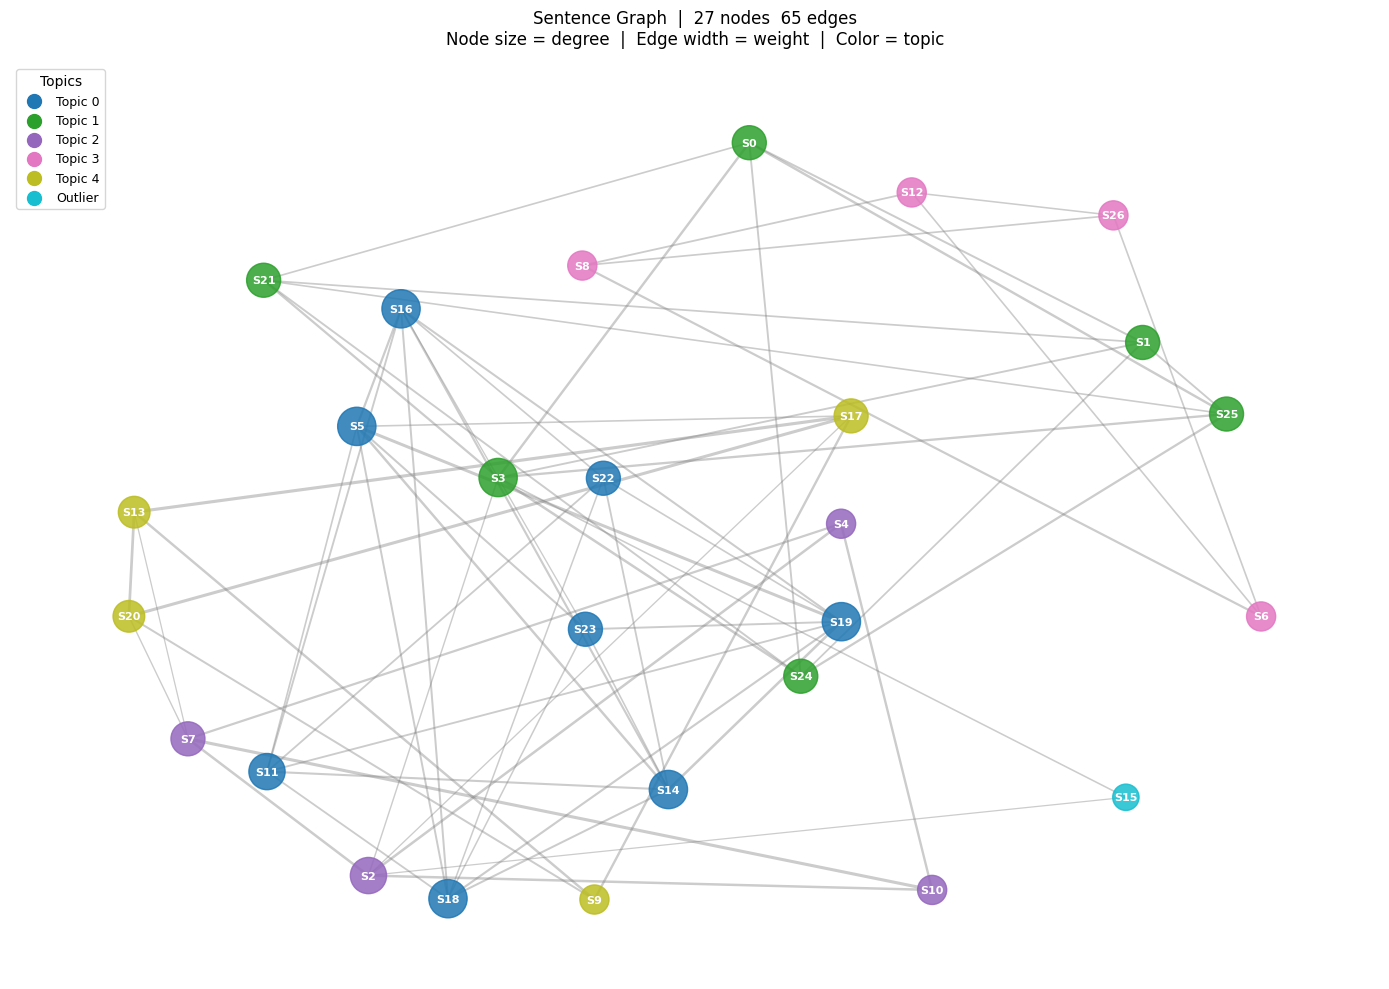

In [22]:
def visualize_graph(G, article, max_nodes=40):
    """
    Visualize graph with nodes colored by topic_id.
    Node size = degree. Edge thickness = weight.
    """
    # limit to first max_nodes for readability
    nodes_to_show = list(G.nodes())[:max_nodes]
    subG          = G.subgraph(nodes_to_show)

    # layout
    pos           = nx.spring_layout(subG, seed=42, k=1.5)

    # node colors by topic
    topic_ids     = [G.nodes[n]['topic_id'] for n in subG.nodes()]
    unique_tids   = list(set(topic_ids))
    color_map     = plt.cm.get_cmap('tab10', len(unique_tids))
    tid_to_color  = {tid: color_map(i) for i, tid in enumerate(unique_tids)}
    node_colors   = [tid_to_color[t] for t in topic_ids]

    # node sizes by degree
    node_sizes    = [200 + 80 * subG.degree(n) for n in subG.nodes()]

    # edge widths by weight
    edge_weights  = [subG[u][v]['weight'] * 3 for u, v in subG.edges()]

    fig, ax = plt.subplots(figsize=(14, 10))

    nx.draw_networkx_nodes(
        subG, pos,
        node_color  = node_colors,
        node_size   = node_sizes,
        alpha       = 0.85,
        ax          = ax
    )
    nx.draw_networkx_edges(
        subG, pos,
        width       = edge_weights,
        alpha       = 0.4,
        edge_color  = 'gray',
        ax          = ax
    )
    nx.draw_networkx_labels(
        subG, pos,
        labels      = {n: f"S{n}" for n in subG.nodes()},
        font_size   = 8,
        font_color  = 'white',
        font_weight = 'bold',
        ax          = ax
    )

    # legend for topics
    for tid, color in tid_to_color.items():
        label = "Outlier" if tid == -1 else f"Topic {tid}"
        ax.scatter([], [], c=[color], s=100, label=label)
    ax.legend(loc='upper left', fontsize=9, title="Topics")

    ax.set_title(
        f"Sentence Graph  |  {subG.number_of_nodes()} nodes  "
        f"{subG.number_of_edges()} edges\n"
        f"Node size = degree  |  Edge width = weight  "
        f"|  Color = topic",
        fontsize=12, pad=14
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()


visualize_graph(G, article, max_nodes=min(40, n_sents))

In [23]:
print("=" * 65)
print("✓ Step 3 Complete — Graph Summary")
print("=" * 65)
print(f"  Nodes (sentences)  : {G.number_of_nodes()}")
print(f"  Edges              : {G.number_of_edges()}")
print(f"  Graph density      : {nx.density(G):.4f}")
print(f"  Avg degree         : {np.mean([d for _,d in G.degree()]):.2f}")
print(f"  Is connected       : {nx.is_connected(G)}")
print()
print(f"  Edge weight matrix : {edge_weight_matrix.shape}")
print(f"  α (semantic)       : {CONFIG['edge_alpha']}")
print(f"  β (topic)          : {CONFIG['edge_beta']}")
print(f"  γ (entity)         : {CONFIG['edge_gamma']}")
print(f"  Threshold          : {CONFIG['edge_threshold']}")
print(f"  Top-K neighbors    : {CONFIG['top_k_neighbors']}")
print()
print("Stored in article dict:")
print("  article['graph']              → nx.Graph")
print("  article['edge_weight_matrix'] → np.array (n×n)")
print("  article['semantic_sim_matrix']→ np.array (n×n)")
print("  article['topic_sim_matrix']   → np.array (n×n)")
print("  article['entity_sim_matrix']  → np.array (n×n)")
print()
print("Say 'next' for Step 4: Community Detection + Graph Scoring")

✓ Step 3 Complete — Graph Summary
  Nodes (sentences)  : 27
  Edges              : 65
  Graph density      : 0.1852
  Avg degree         : 4.81
  Is connected       : False

  Edge weight matrix : (27, 27)
  α (semantic)       : 0.5
  β (topic)          : 0.3
  γ (entity)         : 0.2
  Threshold          : 0.3
  Top-K neighbors    : 7

Stored in article dict:
  article['graph']              → nx.Graph
  article['edge_weight_matrix'] → np.array (n×n)
  article['semantic_sim_matrix']→ np.array (n×n)
  article['topic_sim_matrix']   → np.array (n×n)
  article['entity_sim_matrix']  → np.array (n×n)

Say 'next' for Step 4: Community Detection + Graph Scoring


## Step 4: Community Detection + Graph Scoring

### Handle Disconnected Graph

In [24]:
# ── If graph is disconnected, work on largest component ───────
if not nx.is_connected(G):
    components  = list(nx.connected_components(G))
    print(f"Graph has {len(components)} components")
    print(f"  Sizes: {sorted([len(c) for c in components], reverse=True)}")

    # take largest connected component
    largest_cc  = max(components, key=len)
    G_work      = G.subgraph(largest_cc).copy()
    print(f"\nWorking on largest component: {G_work.number_of_nodes()} nodes")
else:
    G_work      = G
    print(f"Graph is connected. Working on full graph: {G_work.number_of_nodes()} nodes")

article['G_work'] = G_work

Graph has 2 components
  Sizes: [23, 4]

Working on largest component: 23 nodes


### Community Detection (Louvain)

In [25]:
# ── Fallback: NetworkX greedy modularity communities ──────────
from networkx.algorithms import community as nx_community

print("Running community detection (NetworkX greedy modularity)...")

# greedy modularity works on weighted undirected graphs
communities_generator = nx_community.greedy_modularity_communities(
    G_work,
    weight = 'weight',
)

communities_list = [sorted(c) for c in communities_generator]

# build partition dict {node: community_id}
partition = {}
for comm_id, members in enumerate(communities_list):
    for node in members:
        partition[node] = comm_id

# build communities dict {community_id: [nodes]}
communities = defaultdict(list)
for node, comm_id in partition.items():
    communities[comm_id].append(node)

n_communities = len(communities)

# compute modularity manually
modularity_score = nx_community.modularity(
    G_work,
    communities_list,
    weight = 'weight'
)

print(f"\n✓ Community detection complete")
print(f"  Communities found : {n_communities}")
print(f"  Modularity score  : {modularity_score:.4f}")

# store community id back into graph nodes
nx.set_node_attributes(G_work, partition, name='community_id')

# store in article
article['partition']   = partition
article['communities'] = communities
article['modularity']  = modularity_score

Running community detection (NetworkX greedy modularity)...

✓ Community detection complete
  Communities found : 4
  Modularity score  : 0.6351


In [26]:
#!pip uninstall -y python-louvain community
#!pip install python-louvain

In [27]:
# REPLACE this:
#import community as community_louvain

# WITH this:
#import importlib
#import community as community_louvain
#print(dir(community_louvain))          # verify best_partition is listed

### Inspect Communities

In [28]:
print("\nCommunity breakdown:")
print("-" * 65)

for comm_id in sorted(communities.keys()):
    member_nodes = communities[comm_id]
    member_texts = [article['sentences'][n]['text'] for n in member_nodes
                    if n < len(article['sentences'])]
    topic_ids    = [article['sentences'][n]['topic_id'] for n in member_nodes
                    if n < len(article['sentences'])]

    # dominant BERTopic topic in this community
    from collections import Counter
    dominant_topic = Counter(topic_ids).most_common(1)[0][0]

    print(f"\n  Community {comm_id}  "
          f"({len(member_nodes)} sentences)  "
          f"dominant BERTopic topic: {dominant_topic}")
    print(f"  {'─'*55}")

    # show first 2 sentences
    for node in member_nodes[:2]:
        if node < len(article['sentences']):
            txt = article['sentences'][node]['text']
            print(f"    S{node:02d}: {txt[:100]}...")
    if len(member_nodes) > 2:
        print(f"    ... and {len(member_nodes)-2} more sentences")


Community breakdown:
-----------------------------------------------------------------

  Community 0  (8 sentences)  dominant BERTopic topic: 0
  ───────────────────────────────────────────────────────
    S05: Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts t...
    S11: These are substantive commitments, which cannot be taken lightly," she said....
    ... and 6 more sentences

  Community 1  (6 sentences)  dominant BERTopic topic: 1
  ───────────────────────────────────────────────────────
    S00: The Palestinian Authority officially became the 123rd member of the International Criminal Court on ...
    S01: The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is...
    ... and 4 more sentences

  Community 2  (5 sentences)  dominant BERTopic topic: 2
  ───────────────────────────────────────────────────────
    S02: The Palestinians signed the ICC's founding Rome Statute in January, w

### Compute Community-Level Statistics

In [29]:
def compute_community_stats(G_work, communities, article) -> dict:
    """
    For each community compute:
      - size
      - internal edge density
      - mean internal edge weight
      - member node ids
    These feed into topic_importance later.
    """
    stats = {}

    for comm_id, members in communities.items():
        subgraph      = G_work.subgraph(members)
        n_members     = len(members)

        # internal edges
        internal_edges = list(subgraph.edges(data=True))
        n_internal     = len(internal_edges)

        # max possible edges in subgraph
        max_edges      = n_members * (n_members - 1) / 2
        density        = n_internal / max_edges if max_edges > 0 else 0.0

        # mean internal edge weight
        if n_internal > 0:
            mean_weight = np.mean([d['weight'] for _, _, d in internal_edges])
        else:
            mean_weight = 0.0

        stats[comm_id] = {
            "size"        : n_members,
            "n_edges"     : n_internal,
            "density"     : round(density, 4),
            "mean_weight" : round(float(mean_weight), 4),
            "members"     : members,
        }

    return stats


community_stats = compute_community_stats(G_work, communities, article)
article['community_stats'] = community_stats

print("Community Statistics:")
print("-" * 65)
print(f"  {'CommID':<8} {'Size':>6} {'Edges':>7} "
      f"{'Density':>9} {'MeanWeight':>12}")
print(f"  {'─'*50}")
for cid, s in sorted(community_stats.items()):
    print(f"  {cid:<8} {s['size']:>6} {s['n_edges']:>7} "
          f"{s['density']:>9.4f} {s['mean_weight']:>12.4f}")

Community Statistics:
-----------------------------------------------------------------
  CommID     Size   Edges   Density   MeanWeight
  ──────────────────────────────────────────────────
  0             8      25    0.8929       0.4703
  1             6      15    1.0000       0.4899
  2             5       7    0.7000       0.5642
  3             4       6    1.0000       0.6279


### Step A: Global PageRank

In [30]:
print("\nComputing Global PageRank...")

pagerank_scores = nx.pagerank(
    G_work,
    alpha    = CONFIG['damping_factor'],    # 0.85
    weight   = 'weight',
    tol      = CONFIG['pagerank_tol'],
    max_iter = CONFIG['pagerank_max_iter'],
)

# normalize to [0,1]
pr_values  = np.array(list(pagerank_scores.values()))
pr_min, pr_max = pr_values.min(), pr_values.max()
pagerank_norm  = {
    node: (score - pr_min) / (pr_max - pr_min + 1e-8)
    for node, score in pagerank_scores.items()
}

print(f"✓ PageRank computed")
print(f"  Min    : {pr_values.min():.6f}")
print(f"  Max    : {pr_values.max():.6f}")
print(f"  Mean   : {pr_values.mean():.6f}")
print(f"\nTop 5 nodes by PageRank:")
top_pr = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_pr:
    txt = article['sentences'][node]['text'][:80]
    print(f"  S{node:02d} ({score:.5f}): {txt}...")

article['pagerank_scores'] = pagerank_scores
article['pagerank_norm']   = pagerank_norm


Computing Global PageRank...
✓ PageRank computed
  Min    : 0.017354
  Max    : 0.062709
  Mean   : 0.043478

Top 5 nodes by PageRank:
  S03 (0.06271): Later that month, the ICC opened a preliminary examination into the situation in...
  S02 (0.05431): The Palestinians signed the ICC's founding Rome Statute in January, when they al...
  S19 (0.05318): "We will continue to oppose actions against Israel at the ICC as counterproducti...
  S05 (0.05305): Israel and the United States, neither of which is an ICC member, opposed the Pal...
  S14 (0.05147): "What's objectionable is the attempts to undermine international justice, not Pa...


### Step B: Topic Importance (Graph-Derived)

In [31]:
# ── topic_importance(T) = sum of PageRank of all nodes in T ───
# normalized by total PageRank mass → no external signal needed

print("\nComputing topic importance from PageRank mass...")

total_pr        = sum(pagerank_scores.values())
topic_importance = {}

for comm_id, members in communities.items():
    comm_pr = sum(pagerank_scores.get(n, 0.0) for n in members)
    topic_importance[comm_id] = comm_pr / total_pr

# verify sums to 1
ti_sum = sum(topic_importance.values())
print(f"✓ Topic importance computed (sum = {ti_sum:.4f})")
print(f"\n  {'CommID':<8} {'Importance':>12} {'Size':>6} {'Interpretation'}")
print(f"  {'─'*55}")
for cid in sorted(topic_importance, key=topic_importance.get, reverse=True):
    bar = "█" * int(topic_importance[cid] * 40)
    print(f"  {cid:<8} {topic_importance[cid]:>12.4f} "
          f"{community_stats[cid]['size']:>6}   {bar}")

article['topic_importance'] = topic_importance


Computing topic importance from PageRank mass...
✓ Topic importance computed (sum = 1.0000)

  CommID     Importance   Size Interpretation
  ───────────────────────────────────────────────────────
  0              0.3557      8   ██████████████
  1              0.2797      6   ███████████
  2              0.1950      5   ███████
  3              0.1696      4   ██████


### Step C: Local Community Centrality

In [32]:
# ── PageRank within each community subgraph ───────────────────
print("\nComputing local community centrality...")

local_centrality = {}                       # {node_id: local_pr_score}

for comm_id, members in communities.items():
    subgraph = G_work.subgraph(members).copy()

    if subgraph.number_of_nodes() == 1:
        # single node community → centrality = 1.0
        local_centrality[members[0]] = 1.0
        continue

    if subgraph.number_of_edges() == 0:
        # no edges → uniform centrality
        for n in members:
            local_centrality[n] = 1.0 / len(members)
        continue

    local_pr = nx.pagerank(
        subgraph,
        alpha    = CONFIG['damping_factor'],
        weight   = 'weight',
        tol      = CONFIG['pagerank_tol'],
        max_iter = CONFIG['pagerank_max_iter'],
    )

    # normalize within community
    lpr_vals  = list(local_pr.values())
    lpr_min, lpr_max = min(lpr_vals), max(lpr_vals)
    for node, score in local_pr.items():
        local_centrality[node] = (score - lpr_min) / (lpr_max - lpr_min + 1e-8)

print(f"✓ Local centrality computed for {len(local_centrality)} nodes")

article['local_centrality'] = local_centrality


Computing local community centrality...
✓ Local centrality computed for 23 nodes


### Step D: Betweenness Centrality

In [33]:
# ── Betweenness: how often a node sits on shortest paths ──────
print("\nComputing betweenness centrality...")

betweenness_scores = nx.betweenness_centrality(
    G_work,
    weight      = 'weight',        # use edge weights as distances
    normalized  = True,
)

# normalize to [0,1]
bw_vals   = np.array(list(betweenness_scores.values()))
bw_min, bw_max = bw_vals.min(), bw_vals.max()
betweenness_norm = {
    node: (score - bw_min) / (bw_max - bw_min + 1e-8)
    for node, score in betweenness_scores.items()
}

print(f"✓ Betweenness centrality computed")
print(f"  Min    : {bw_vals.min():.6f}")
print(f"  Max    : {bw_vals.max():.6f}")
print(f"  Mean   : {bw_vals.mean():.6f}")

print(f"\nTop 5 bridge nodes (high betweenness):")
top_bw = sorted(betweenness_scores.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_bw:
    comm = partition[node]
    txt  = article['sentences'][node]['text'][:80]
    print(f"  S{node:02d} (bw={score:.5f}, comm={comm}): {txt}...")

article['betweenness_scores'] = betweenness_scores
article['betweenness_norm']   = betweenness_norm


Computing betweenness centrality...
✓ Betweenness centrality computed
  Min    : 0.000000
  Max    : 0.575758
  Mean   : 0.091474

Top 5 bridge nodes (high betweenness):
  S02 (bw=0.57576, comm=2): The Palestinians signed the ICC's founding Rome Statute in January, when they al...
  S17 (bw=0.52381, comm=3): "As we have said repeatedly, we do not believe that Palestine is a state and the...
  S05 (bw=0.45455, comm=0): Israel and the United States, neither of which is an ICC member, opposed the Pal...
  S03 (bw=0.36797, comm=1): Later that month, the ICC opened a preliminary examination into the situation in...
  S07 (bw=0.09524, comm=2): "As Palestine formally becomes a State Party to the Rome Statute today, the worl...


### Step E: Final Node Score (All Components Fused)

In [34]:
def compute_final_scores(
    G_work,
    pagerank_norm,
    local_centrality,
    betweenness_norm,
    topic_importance,
    partition,
    sentences,
    lambda_global   = 0.5,
    lambda_local    = 0.3,
    lambda_between  = 0.2,
) -> dict:
    """
    final_score(Si) =
        ( λ_g × global_pagerank(Si)
        + λ_l × local_centrality(Si)
        + λ_b × betweenness(Si) )
        × topic_importance(cluster(Si))
        × position_weight(Si)
    """
    final_scores = {}

    for node in G_work.nodes():
        comm_id  = partition[node]

        # weighted sum of centrality components
        centrality_score = (
              lambda_global  * pagerank_norm.get(node, 0.0)
            + lambda_local   * local_centrality.get(node, 0.0)
            + lambda_between * betweenness_norm.get(node, 0.0)
        )

        # multiply by graph-derived topic importance
        ti_score  = topic_importance.get(comm_id, 0.0)

        # multiply by position weight
        pos_w     = sentences[node]['position_weight'] \
                    if node < len(sentences) else 1.0

        final_scores[node] = centrality_score * ti_score * pos_w

    return final_scores


final_scores = compute_final_scores(
    G_work           = G_work,
    pagerank_norm    = pagerank_norm,
    local_centrality = local_centrality,
    betweenness_norm = betweenness_norm,
    topic_importance = topic_importance,
    partition        = partition,
    sentences        = article['sentences'],
    lambda_global    = CONFIG['lambda_global'],
    lambda_local     = CONFIG['lambda_local'],
    lambda_between   = CONFIG['lambda_between'],
)

article['final_scores'] = final_scores

print("✓ Final scores computed")
print(f"\nTop 10 ranked sentences:")
print("-" * 65)
top_nodes = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:10]
for rank, (node, score) in enumerate(top_nodes, 1):
    comm   = partition[node]
    ti     = topic_importance[comm]
    pr     = pagerank_norm[node]
    bw     = betweenness_norm[node]
    lc     = local_centrality[node]
    txt    = article['sentences'][node]['text'][:85]
    print(f"\n  [{rank:02d}] S{node:02d}  final={score:.5f}  "
          f"comm={comm}  ti={ti:.3f}")
    print(f"        pr={pr:.3f}  local={lc:.3f}  bw={bw:.3f}")
    print(f"        \"{txt}...\"")

✓ Final scores computed

Top 10 ranked sentences:
-----------------------------------------------------------------

  [01] S00  final=0.18898  comm=1  ti=0.280
        pr=0.612  local=0.540  bw=0.000
        "The Palestinian Authority officially became the 123rd member of the International Cri..."

  [02] S03  final=0.16125  comm=1  ti=0.280
        pr=1.000  local=1.000  bw=0.639
        "Later that month, the ICC opened a preliminary examination into the situation in Pale..."

  [03] S05  final=0.13979  comm=0  ti=0.356
        pr=0.787  local=0.711  bw=0.789
        "Israel and the United States, neither of which is an ICC member, opposed the Palestin..."

  [04] S02  final=0.12761  comm=2  ti=0.195
        pr=0.815  local=1.000  bw=1.000
        "The Palestinians signed the ICC's founding Rome Statute in January, when they also ac..."

  [05] S14  final=0.08367  comm=0  ti=0.356
        pr=0.752  local=0.920  bw=0.000
        ""What's objectionable is the attempts to undermine int

### Visualize Scores

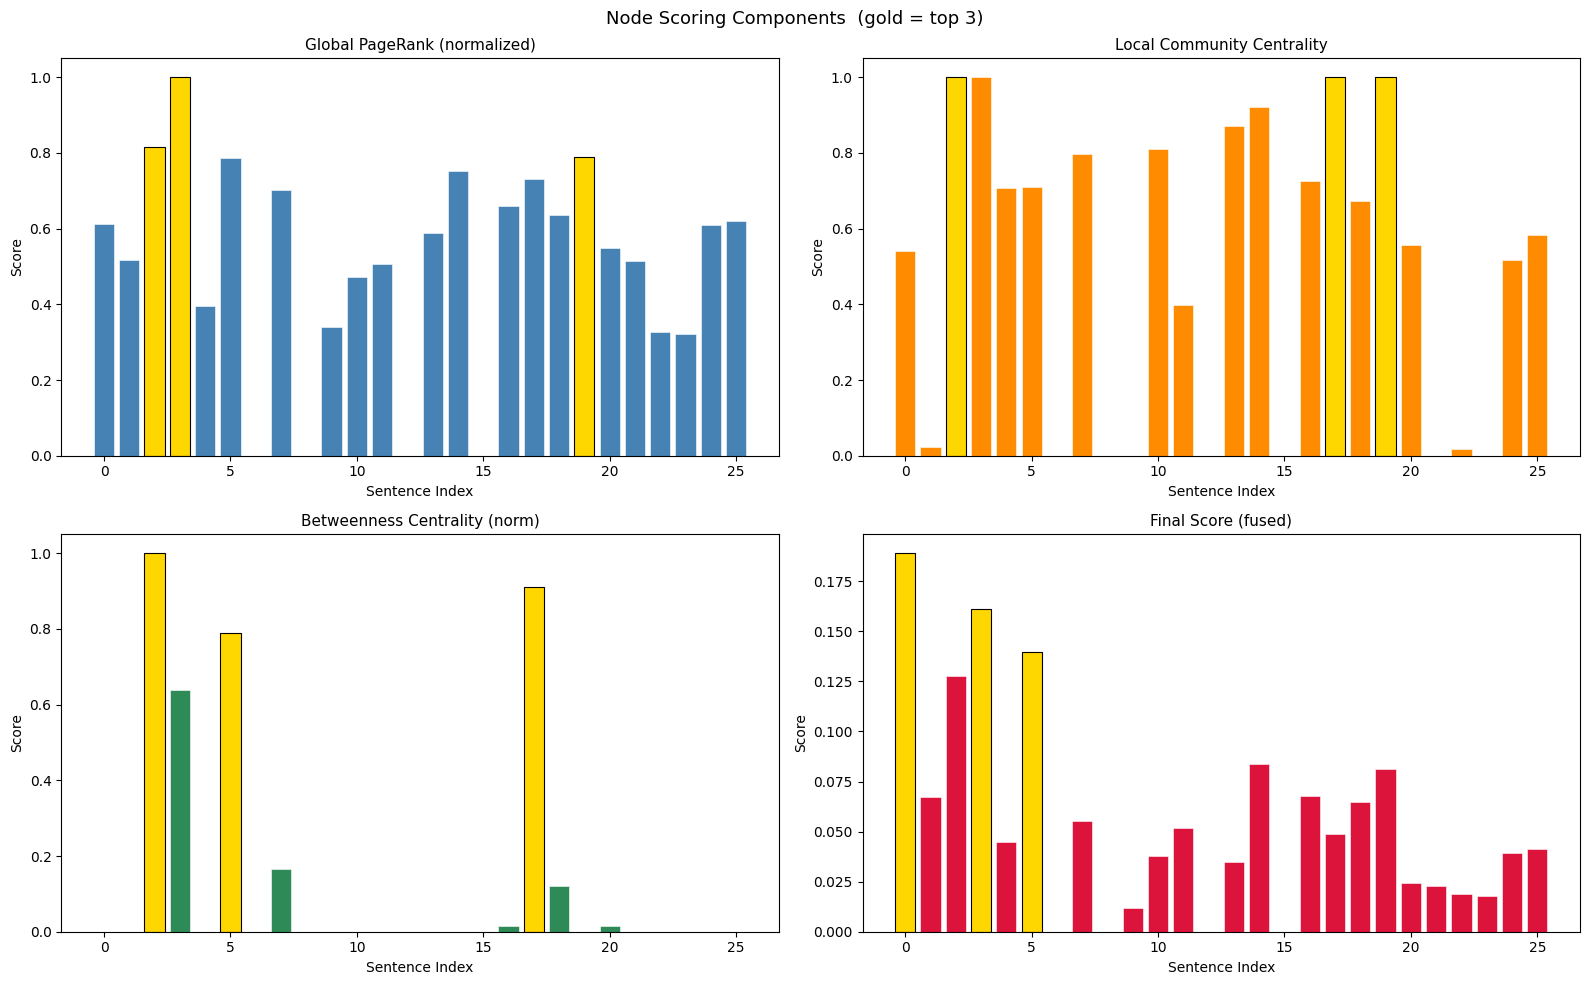

In [35]:
nodes_sorted = sorted(final_scores.keys())
fig, axes    = plt.subplots(2, 2, figsize=(16, 10))

score_sets = [
    (pagerank_norm,    "Global PageRank (normalized)",    'steelblue'),
    (local_centrality, "Local Community Centrality",      'darkorange'),
    (betweenness_norm, "Betweenness Centrality (norm)",   'seagreen'),
    (final_scores,     "Final Score (fused)",             'crimson'),
]

for ax, (scores, title, color) in zip(axes.flat, score_sets):
    vals = [scores.get(n, 0) for n in nodes_sorted]
    ax.bar(nodes_sorted, vals, color=color, edgecolor='white', linewidth=0.4)
    ax.set_xlabel("Sentence Index")
    ax.set_ylabel("Score")
    ax.set_title(title, fontsize=11)

    # highlight top 3
    top3 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]
    for node, _ in top3:
        ax.bar(node, scores[node], color='gold',
               edgecolor='black', linewidth=0.8)

plt.suptitle("Node Scoring Components  (gold = top 3)", fontsize=13)
plt.tight_layout()
plt.show()

### Visualize Graph Colored by Community + Final Score

/tmp/ipykernel_10198/2397496152.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = plt.cm.get_cmap('tab10', len(comm_ids))


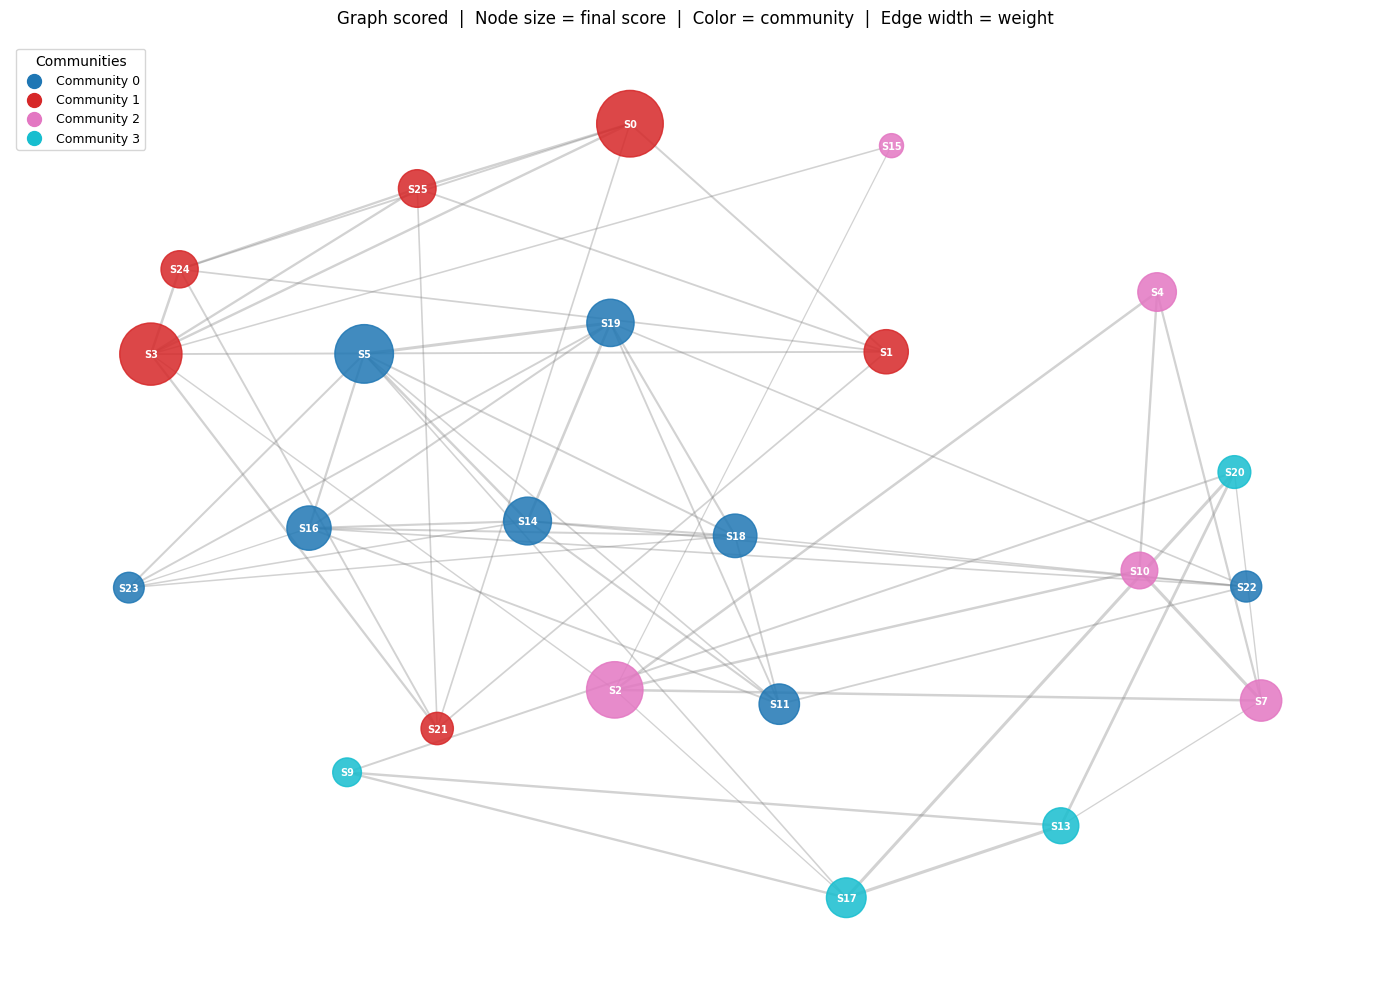

In [36]:
fig, ax  = plt.subplots(figsize=(14, 10))
pos      = nx.spring_layout(G_work, seed=42, k=1.5)

# node color = community
comm_ids    = list(set(partition.values()))
cmap        = plt.cm.get_cmap('tab10', len(comm_ids))
cid_to_col  = {cid: cmap(i) for i, cid in enumerate(comm_ids)}
node_colors = [cid_to_col[partition[n]] for n in G_work.nodes()]

# node size = final score
max_score   = max(final_scores.values()) + 1e-8
node_sizes  = [
    300 + 2000 * final_scores.get(n, 0) / max_score
    for n in G_work.nodes()
]

# edge width = weight
edge_widths = [G_work[u][v]['weight'] * 3 for u, v in G_work.edges()]

nx.draw_networkx_nodes(G_work, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_work, pos, width=edge_widths,
                       alpha=0.35, edge_color='gray', ax=ax)
nx.draw_networkx_labels(G_work, pos,
                        labels={n: f"S{n}" for n in G_work.nodes()},
                        font_size=7, font_color='white',
                        font_weight='bold', ax=ax)

for cid, color in cid_to_col.items():
    ax.scatter([], [], c=[color], s=100, label=f"Community {cid}")
ax.legend(loc='upper left', fontsize=9, title="Communities")

ax.set_title(
    "Graph scored  |  Node size = final score  "
    "|  Color = community  |  Edge width = weight",
    fontsize=12, pad=14
)
ax.axis('off')
plt.tight_layout()
plt.show()

In [37]:
print("=" * 65)
print("✓ Step 4 Complete — Scoring Summary")
print("=" * 65)
print(f"  Communities detected  : {n_communities}")
print(f"  Modularity            : {modularity_score:.4f}")
print()
print(f"  Scoring components:")
print(f"    λ_global  = {CONFIG['lambda_global']}  → Global PageRank")
print(f"    λ_local   = {CONFIG['lambda_local']}  → Local Centrality")
print(f"    λ_between = {CONFIG['lambda_between']}  → Betweenness")
print()
print(f"  Topic importance (graph-derived, no external signal):")
for cid in sorted(topic_importance, key=topic_importance.get, reverse=True):
    print(f"    Community {cid}: {topic_importance[cid]:.4f}")
print()
print(f"  Top 3 sentences by final score:")
for node, score in top_nodes[:3]:
    print(f"    S{node:02d} (score={score:.5f}): "
          f"{article['sentences'][node]['text'][:70]}...")
print()
print("Say 'next' for Step 5: Topic-Aware Sentence Selection + MMR")

✓ Step 4 Complete — Scoring Summary
  Communities detected  : 4
  Modularity            : 0.6351

  Scoring components:
    λ_global  = 0.5  → Global PageRank
    λ_local   = 0.3  → Local Centrality
    λ_between = 0.2  → Betweenness

  Topic importance (graph-derived, no external signal):
    Community 0: 0.3557
    Community 1: 0.2797
    Community 2: 0.1950
    Community 3: 0.1696

  Top 3 sentences by final score:
    S00 (score=0.18898): The Palestinian Authority officially became the 123rd member of the In...
    S03 (score=0.16125): Later that month, the ICC opened a preliminary examination into the si...
    S05 (score=0.13979): Israel and the United States, neither of which is an ICC member, oppos...

Say 'next' for Step 5: Topic-Aware Sentence Selection + MMR


## Step 5: Topic-Aware Sentence Selection + MMR

### Budget Allocation Per Community

In [38]:
# ── Proportional sentence budget per community ─────────────────
# budget(T) = topic_importance(T) × total_summary_sentences
# No external signal — fully driven by graph-derived importance

total_sentences  = CONFIG['summary_sentences']      # 8
bridge_budget    = CONFIG['bridge_sentences']        # 2
selection_budget = total_sentences - bridge_budget   # 6 for topic sentences

print(f"Summary budget allocation:")
print(f"  Total summary sentences : {total_sentences}")
print(f"  Bridge sentences        : {bridge_budget}")
print(f"  Topic sentences         : {selection_budget}")
print()

# ── Allocate per community ────────────────────────────────────
raw_budgets  = {}
for comm_id, importance in topic_importance.items():
    raw_budgets[comm_id] = importance * selection_budget

# floor allocation
floor_budgets = {cid: max(1, int(np.floor(b)))
                 for cid, b in raw_budgets.items()}

# distribute remaining slots to communities
# with highest fractional parts
allocated    = sum(floor_budgets.values())
remainder    = selection_budget - allocated

if remainder > 0:
    # sort by fractional part descending
    fractional   = {cid: raw_budgets[cid] - int(np.floor(raw_budgets[cid]))
                    for cid in raw_budgets}
    sorted_frac  = sorted(fractional, key=fractional.get, reverse=True)
    for cid in sorted_frac[:remainder]:
        floor_budgets[cid] += 1

community_budgets = floor_budgets

print(f"Community budget allocation:")
print(f"  {'CommID':<10} {'Importance':>12} {'RawBudget':>11} {'Budget':>8}")
print(f"  {'─'*45}")
for cid in sorted(community_budgets, key=topic_importance.get, reverse=True):
    print(f"  {cid:<10} {topic_importance[cid]:>12.4f} "
          f"{raw_budgets[cid]:>11.3f} {community_budgets[cid]:>8}")
print(f"  {'─'*45}")
print(f"  {'TOTAL':<10} {'':>12} {'':>11} {sum(community_budgets.values()):>8}")

article['community_budgets'] = community_budgets

Summary budget allocation:
  Total summary sentences : 10
  Bridge sentences        : 2
  Topic sentences         : 8

Community budget allocation:
  CommID       Importance   RawBudget   Budget
  ─────────────────────────────────────────────
  0                0.3557       2.846        3
  1                0.2797       2.238        2
  2                0.1950       1.560        2
  3                0.1696       1.357        1
  ─────────────────────────────────────────────
  TOTAL                                      8


### Per-Community Candidate Ranking

In [39]:
# ── Rank sentences within each community by final_score ───────
community_candidates = {}                   # {comm_id: [nodes ranked]}

print("\nPer-community candidate ranking:")
print("-" * 65)

for comm_id, members in communities.items():
    # filter to nodes present in G_work
    valid_members = [n for n in members if n in final_scores]

    # rank by final score descending
    ranked = sorted(
        valid_members,
        key     = lambda n: final_scores[n],
        reverse = True
    )
    community_candidates[comm_id] = ranked

    budget = community_budgets.get(comm_id, 1)
    print(f"\n  Community {comm_id}  "
          f"(budget={budget}, candidates={len(ranked)})")
    print(f"  {'─'*55}")
    for rank, node in enumerate(ranked[:budget+1], 1):     # show budget+1
        score = final_scores[node]
        txt   = article['sentences'][node]['text'][:75]
        marker = " ← selected" if rank <= budget else " ← reserve"
        print(f"  [{rank}] S{node:02d} ({score:.5f}){marker}")
        print(f"       \"{txt}...\"")

article['community_candidates'] = community_candidates


Per-community candidate ranking:
-----------------------------------------------------------------

  Community 0  (budget=3, candidates=8)
  ───────────────────────────────────────────────────────
  [1] S05 (0.13979) ← selected
       "Israel and the United States, neither of which is an ICC member, opposed th..."
  [2] S14 (0.08367) ← selected
       ""What's objectionable is the attempts to undermine international justice, n..."
  [3] S19 (0.08120) ← selected
       ""We will continue to oppose actions against Israel at the ICC as counterpro..."
  [4] S16 (0.06786) ← reserve
       "The United States also said it "strongly" disagreed with the court's decisi..."

  Community 1  (budget=2, candidates=6)
  ───────────────────────────────────────────────────────
  [1] S00 (0.18898) ← selected
       "The Palestinian Authority officially became the 123rd member of the Interna..."
  [2] S03 (0.16125) ← selected
       "Later that month, the ICC opened a preliminary examination into the s

### Initial Per-Community Selection (Pre-MMR)

In [40]:
# ── Select top-budget sentences per community ─────────────────
pre_mmr_selected = {}                       # {comm_id: [node_ids]}
all_pre_mmr      = []                       # flat list

for comm_id, ranked in community_candidates.items():
    budget   = community_budgets.get(comm_id, 1)
    selected = ranked[:budget]
    pre_mmr_selected[comm_id] = selected
    all_pre_mmr.extend(selected)

print(f"Pre-MMR selection: {len(all_pre_mmr)} sentences")
print(f"  Nodes: {sorted(all_pre_mmr)}")

article['pre_mmr_selected'] = pre_mmr_selected

Pre-MMR selection: 8 sentences
  Nodes: [0, 2, 3, 5, 7, 14, 17, 19]


### MMR — Cross-Topic Deduplication

In [41]:
def mmr_selection(
    candidates,
    embeddings,
    final_scores,
    mmr_lambda   = 0.7,
    budget       = 6,
) -> list:
    """
    Maximal Marginal Relevance across all topic candidates.

    Iteratively selects sentence that maximizes:
      MMR(Si) = λ × final_score(Si)
              - (1-λ) × max cosine_sim(Si, already_selected)

    Parameters:
      candidates   : list of node ids to consider
      embeddings   : np.array (n_sentences × dim)
      final_scores : dict {node_id: score}
      mmr_lambda   : relevance vs diversity tradeoff
      budget       : number of sentences to select

    Returns:
      ordered list of selected node ids
    """
    selected     = []
    remaining    = list(candidates)

    while len(selected) < budget and remaining:

        if len(selected) == 0:
            # first pick = highest scoring candidate
            best = max(remaining, key=lambda n: final_scores.get(n, 0))
            selected.append(best)
            remaining.remove(best)
            continue

        # embeddings of already selected sentences
        selected_embs = embeddings[selected]    # shape: (k × dim)

        best_node  = None
        best_score = -np.inf

        for node in remaining:
            node_emb   = embeddings[node].reshape(1, -1)

            # relevance term
            relevance  = final_scores.get(node, 0.0)

            # redundancy term: max cosine sim to any selected sentence
            sims       = cosine_similarity(node_emb, selected_embs)[0]
            redundancy = float(sims.max())

            # MMR score
            mmr_score  = (mmr_lambda * relevance
                         - (1 - mmr_lambda) * redundancy)

            if mmr_score > best_score:
                best_score = mmr_score
                best_node  = node

        if best_node is not None:
            selected.append(best_node)
            remaining.remove(best_node)

    return selected


# ── Run MMR on all pre-selected candidates ────────────────────
print("Running MMR deduplication across all topic candidates...")
print(f"  Input candidates : {len(all_pre_mmr)}")
print(f"  MMR λ            : {CONFIG['mmr_lambda']}")
print(f"  Budget           : {selection_budget}")

mmr_selected = mmr_selection(
    candidates   = all_pre_mmr,
    embeddings   = article['embeddings'],
    final_scores = final_scores,
    mmr_lambda   = CONFIG['mmr_lambda'],
    budget       = selection_budget,
)

print(f"\n✓ MMR selection complete")
print(f"  Selected nodes : {mmr_selected}")

article['mmr_selected'] = mmr_selected

Running MMR deduplication across all topic candidates...
  Input candidates : 8
  MMR λ            : 0.7
  Budget           : 8

✓ MMR selection complete
  Selected nodes : [0, 5, 3, 2, 14, 19, 7, 17]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Bridge Sentence Selection

In [42]:
# ── Bridge sentences: high betweenness, not already selected ──
# These link multiple communities → improve cross-topic coherence

print(f"\nSelecting {bridge_budget} bridge sentences...")

# rank all unselected nodes by betweenness score
unselected_nodes = [
    n for n in G_work.nodes()
    if n not in mmr_selected
]

# sort by betweenness descending
bridge_candidates = sorted(
    unselected_nodes,
    key     = lambda n: betweenness_scores.get(n, 0),
    reverse = True
)

# take top bridge_budget
bridge_nodes = bridge_candidates[:bridge_budget]

print(f"✓ Bridge sentences selected")
for node in bridge_nodes:
    bw    = betweenness_scores[node]
    comm  = partition[node]
    txt   = article['sentences'][node]['text'][:85]
    print(f"\n  S{node:02d}  (betweenness={bw:.5f}, community={comm})")
    print(f"  \"{txt}...\"")

article['bridge_nodes'] = bridge_nodes


Selecting 2 bridge sentences...
✓ Bridge sentences selected

  S18  (betweenness=0.06926, community=0)
  "It urged the warring sides to resolve their differences through direct negotiations...."

  S16  (betweenness=0.00866, community=0)
  "The United States also said it "strongly" disagreed with the court's decision...."


### Combine Final Selection

In [43]:
# ── Merge MMR-selected + bridge sentences ─────────────────────
final_selection = list(mmr_selected) + bridge_nodes

# deduplicate (bridge may overlap with mmr in edge cases)
seen            = set()
final_selection_dedup = []
for n in final_selection:
    if n not in seen:
        final_selection_dedup.append(n)
        seen.add(n)

# ── Sort by original document position for coherent output ────
final_selection_ordered = sorted(
    final_selection_dedup,
    key = lambda n: article['sentences'][n]['sent_id']
)

print(f"✓ Final selection complete")
print(f"  MMR topic sentences : {len(mmr_selected)}")
print(f"  Bridge sentences    : {len(bridge_nodes)}")
print(f"  Total (deduped)     : {len(final_selection_dedup)}")
print(f"  Ordered by position : {final_selection_ordered}")

article['final_selection'] = final_selection_ordered

✓ Final selection complete
  MMR topic sentences : 8
  Bridge sentences    : 2
  Total (deduped)     : 10
  Ordered by position : [0, 2, 3, 5, 7, 14, 16, 17, 18, 19]


### Inspect Final Selected Sentences

In [44]:
print("\n" + "=" * 65)
print("FINAL SELECTED SENTENCES (document order):")
print("=" * 65)

for rank, node in enumerate(final_selection_ordered, 1):
    sent   = article['sentences'][node]
    comm   = partition.get(node, -1)
    score  = final_scores.get(node, 0.0)
    is_bridge = node in bridge_nodes
    tag    = " [BRIDGE]" if is_bridge else ""

    print(f"\n[{rank:02d}] S{node:02d}  "
          f"community={comm}  "
          f"score={score:.5f}"
          f"{tag}")
    print(f"     {sent['text']}")


FINAL SELECTED SENTENCES (document order):

[01] S00  community=1  score=0.18898
     The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories.

[02] S02  community=2  score=0.12761
     The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014."

[03] S03  community=1  score=0.16125
     Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis.

[04] S05  community=0  score=0.13979
     Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join the body.

[05] S07  community=2  score=0.05534
     "As Palestine forma

### Coverage Analysis

In [45]:
# ── Check how many communities are represented ────────────────
covered_communities = set(
    partition.get(n) for n in final_selection_ordered
    if n in partition
)

print("\n" + "=" * 65)
print("COVERAGE ANALYSIS:")
print("=" * 65)
print(f"  Total communities        : {n_communities}")
print(f"  Communities covered      : {len(covered_communities)}")
print(f"  Coverage %               : "
      f"{len(covered_communities)/n_communities*100:.1f}%")
print(f"  Covered community IDs    : {sorted(covered_communities)}")

# ── Redundancy check ──────────────────────────────────────────
selected_embs = article['embeddings'][final_selection_ordered]
sim_matrix    = cosine_similarity(selected_embs)

# average off-diagonal similarity (lower = more diverse)
n_sel         = len(final_selection_ordered)
off_diag_mask = ~np.eye(n_sel, dtype=bool)
avg_redundancy = sim_matrix[off_diag_mask].mean()

print(f"\n  Avg pairwise similarity  : {avg_redundancy:.4f}")
print(f"  (lower = more diverse summary)")

# ── Per-community sentence count in final selection ───────────
print(f"\n  Sentences per community in final selection:")
comm_counts = defaultdict(int)
for n in final_selection_ordered:
    comm_counts[partition.get(n, -1)] += 1
for cid, count in sorted(comm_counts.items()):
    bar = "█" * count
    print(f"    Community {cid}: {count} sentences  {bar}")

article['coverage'] = {
    "n_communities"       : n_communities,
    "covered_communities" : len(covered_communities),
    "coverage_pct"        : len(covered_communities) / n_communities * 100,
    "avg_redundancy"      : float(avg_redundancy),
}


COVERAGE ANALYSIS:
  Total communities        : 4
  Communities covered      : 4
  Coverage %               : 100.0%
  Covered community IDs    : [0, 1, 2, 3]

  Avg pairwise similarity  : 0.4396
  (lower = more diverse summary)

  Sentences per community in final selection:
    Community 0: 5 sentences  █████
    Community 1: 2 sentences  ██
    Community 2: 2 sentences  ██
    Community 3: 1 sentences  █


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Visualize Selection on Score Plot

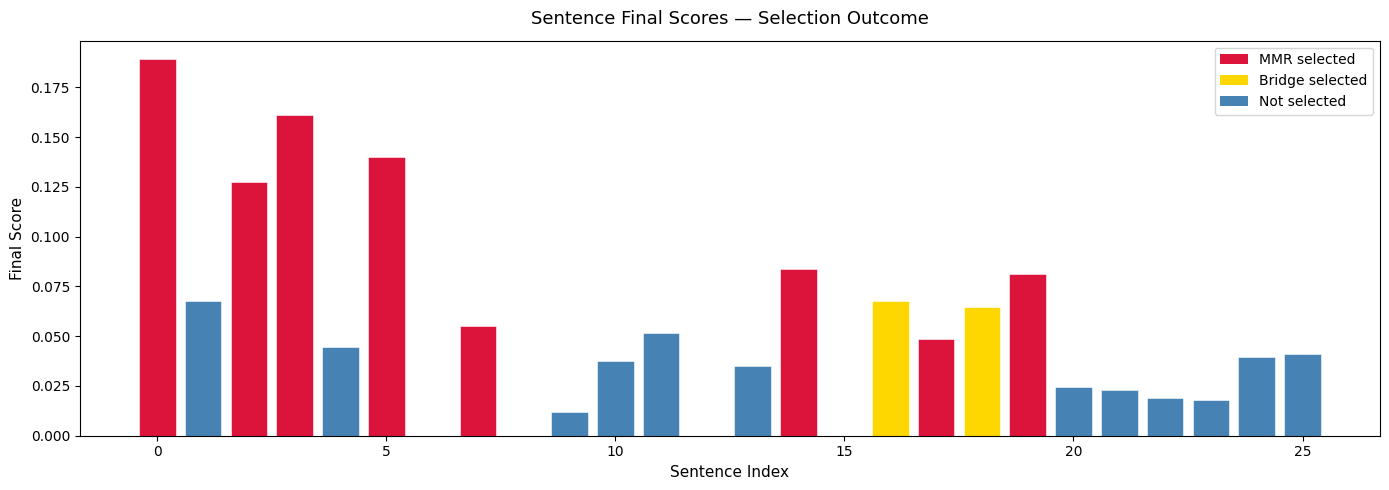

In [46]:
fig, ax   = plt.subplots(figsize=(14, 5))
all_nodes = sorted(final_scores.keys())
all_scores= [final_scores[n] for n in all_nodes]
colors    = []

for n in all_nodes:
    if n in bridge_nodes:
        colors.append('gold')
    elif n in mmr_selected:
        colors.append('crimson')
    else:
        colors.append('steelblue')

bars = ax.bar(all_nodes, all_scores, color=colors,
              edgecolor='white', linewidth=0.4)

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='crimson',   label='MMR selected'),
    Patch(facecolor='gold',      label='Bridge selected'),
    Patch(facecolor='steelblue', label='Not selected'),
]
ax.legend(handles=legend_elements, fontsize=10)

ax.set_xlabel("Sentence Index", fontsize=11)
ax.set_ylabel("Final Score",    fontsize=11)
ax.set_title("Sentence Final Scores — Selection Outcome",
             fontsize=13, pad=12)

plt.tight_layout()
plt.show()

### Checkpoint

In [47]:
print("=" * 65)
print("✓ Step 5 Complete — Selection Summary")
print("=" * 65)
print(f"  Total budget             : {total_sentences}")
print(f"  Topic sentences (MMR)    : {len(mmr_selected)}")
print(f"  Bridge sentences         : {len(bridge_nodes)}")
print(f"  Final selection size     : {len(final_selection_ordered)}")
print(f"  Community coverage       : "
      f"{article['coverage']['covered_communities']}/"
      f"{article['coverage']['n_communities']} "
      f"({article['coverage']['coverage_pct']:.1f}%)")
print(f"  Avg pairwise similarity  : "
      f"{article['coverage']['avg_redundancy']:.4f}")
print()
print(f"  Selected sentence IDs    : {final_selection_ordered}")
print()
print("Say 'next' for Step 6: Summary Generation + Evaluation")

✓ Step 5 Complete — Selection Summary
  Total budget             : 10
  Topic sentences (MMR)    : 8
  Bridge sentences         : 2
  Final selection size     : 10
  Community coverage       : 4/4 (100.0%)
  Avg pairwise similarity  : 0.4396

  Selected sentence IDs    : [0, 2, 3, 5, 7, 14, 16, 17, 18, 19]

Say 'next' for Step 6: Summary Generation + Evaluation


## Step 6: Extractive Summary Generation + Evaluation

### Build Extractive Summary

In [48]:
# ── Stitch selected sentences in document order ───────────────
def build_extractive_summary(
    final_selection_ordered,
    sentences,
    partition,
    bridge_nodes,
) -> str:
    """
    Concatenate selected sentences in original document order.
    Insert simple discourse connectives at community boundaries
    to signal topic transitions.
    """

    # discourse connectives for topic transitions
    transition_phrases = [
        "Additionally,",
        "Furthermore,",
        "In relation to this,",
        "Meanwhile,",
        "On another note,",
    ]

    summary_parts    = []
    prev_community   = None
    transition_idx   = 0

    for node in final_selection_ordered:
        sent      = sentences[node]
        curr_comm = partition.get(node, -1)
        text      = sent['text'].strip()

        # insert transition phrase at community boundary
        if (prev_community is not None
                and curr_comm != prev_community
                and node not in bridge_nodes):

            phrase = transition_phrases[
                transition_idx % len(transition_phrases)
            ]
            transition_idx += 1

            # only prepend if sentence doesn't already
            # start with a connective
            connective_starters = (
                "however", "additionally", "furthermore",
                "meanwhile", "also", "but", "yet", "still",
                "in", "on", "while", "although"
            )
            if not text.lower().startswith(connective_starters):
                text = f"{phrase} {text}"

        summary_parts.append(text)
        prev_community = curr_comm

    # join with single space
    summary = " ".join(summary_parts)
    return summary


# ── Generate summary ──────────────────────────────────────────
extractive_summary = build_extractive_summary(
    final_selection_ordered = final_selection_ordered,
    sentences               = article['sentences'],
    partition               = partition,
    bridge_nodes            = bridge_nodes,
)

article['extractive_summary'] = extractive_summary

print("=" * 65)
print("EXTRACTIVE SUMMARY:")
print("=" * 65)
print(extractive_summary)
print()
print(f"Word count  : {len(extractive_summary.split())}")
print(f"Sentences   : {len(final_selection_ordered)}")

EXTRACTIVE SUMMARY:
The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. Additionally, The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Furthermore, Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. In relation to this, Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join the body. Meanwhile, "As Palestine formally becomes a State Party to the Rome Statute today, the world is also a step closer to ending a long era of impunity and injustice," he said, according to an ICC news release. On 

### Side-by-Side: Summary vs Reference

In [49]:
print("\n" + "=" * 65)
print("REFERENCE SUMMARY:")
print("=" * 65)
print(article['reference'])
print()
print(f"Word count  : {len(article['reference'].split())}")

print("\n" + "=" * 65)
print("COMPARISON:")
print("=" * 65)
print(f"  Generated words  : {len(extractive_summary.split())}")
print(f"  Reference words  : {len(article['reference'].split())}")
print(f"  Compression ratio: "
      f"{len(extractive_summary.split()) / len(' '.join([s['text'] for s in article['sentences']]).split()):.3f}")


REFERENCE SUMMARY:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

Word count  : 36

COMPARISON:
  Generated words  : 257
  Reference words  : 36
  Compression ratio: 0.453


### ROUGE Evaluation

In [50]:
from rouge_score import rouge_scorer as rouge_scorer_lib

# ── Initialize scorer ─────────────────────────────────────────
scorer = rouge_scorer_lib.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer = True
)

# ── Score against reference ───────────────────────────────────
rouge_scores = scorer.score(
    target     = article['reference'],      # reference summary
    prediction = extractive_summary,        # our summary
)

print("ROUGE Scores:")
print("-" * 65)
print(f"  {'Metric':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print(f"  {'─'*44}")
for metric, result in rouge_scores.items():
    print(f"  {metric:<12} "
          f"{result.precision:>10.4f} "
          f"{result.recall:>10.4f} "
          f"{result.fmeasure:>10.4f}")

article['rouge_scores'] = {
    k: {
        "precision": round(v.precision, 4),
        "recall"   : round(v.recall, 4),
        "f1"       : round(v.fmeasure, 4),
    }
    for k, v in rouge_scores.items()
}

ROUGE Scores:
-----------------------------------------------------------------
  Metric        Precision     Recall         F1
  ────────────────────────────────────────────
  rouge1           0.1111     0.8529     0.1966
  rouge2           0.0692     0.5455     0.1229
  rougeL           0.0958     0.7353     0.1695


### BERTScore Evaluation

In [51]:
from bert_score import score as bert_score_fn

print("\nComputing BERTScore (this may take ~30s)...")

P, R, F1 = bert_score_fn(
    cands  = [extractive_summary],
    refs   = [article['reference']],
    lang   = "en",
    verbose= False,
)

bert_p  = round(float(P.mean()), 4)
bert_r  = round(float(R.mean()), 4)
bert_f1 = round(float(F1.mean()), 4)

print(f"\nBERTScore:")
print(f"  {'Metric':<12} {'Score':>10}")
print(f"  {'─'*24}")
print(f"  {'Precision':<12} {bert_p:>10.4f}")
print(f"  {'Recall':<12} {bert_r:>10.4f}")
print(f"  {'F1':<12} {bert_f1:>10.4f}")

article['bert_scores'] = {
    "precision": bert_p,
    "recall"   : bert_r,
    "f1"       : bert_f1,
}


Computing BERTScore (this may take ~30s)...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]


BERTScore:
  Metric            Score
  ────────────────────────
  Precision        0.8258
  Recall           0.9146
  F1               0.8679


### Graph Fidelity Score

In [54]:
# ── What % of top-PageRank nodes are in the final summary ─────
# Measures how well selection preserved graph-important sentences

def graph_fidelity(
    final_selection,
    pagerank_scores,
    top_k = 10
) -> float:
    top_pr_nodes = set(
        sorted(pagerank_scores, key=pagerank_scores.get, reverse=True)[:top_k]
    )
    selected_set = set(final_selection)
    overlap      = top_pr_nodes & selected_set
    return len(overlap) / len(top_pr_nodes)


fidelity = graph_fidelity(
    final_selection = final_selection_ordered,
    pagerank_scores = pagerank_scores,
    top_k           = 10,
)

print(f"\nGraph Fidelity (top-10 PageRank coverage): {fidelity:.4f}")

article['graph_fidelity'] = fidelity


Graph Fidelity (top-10 PageRank coverage): 0.9000


### Position Bias Score

In [52]:
# ── What % of selected sentences come from the first 30% ──────
# CNN/DailyMail articles are lead-biased

n_total    = article['n_sentences']
lead_cutoff= int(0.30 * n_total)
n_from_lead= sum(1 for n in final_selection_ordered if n <= lead_cutoff)
lead_bias  = n_from_lead / len(final_selection_ordered)

print(f"\nPosition Bias:")
print(f"  Article length          : {n_total} sentences")
print(f"  Lead 30% cutoff         : S{lead_cutoff}")
print(f"  Selected from lead 30%  : {n_from_lead}/{len(final_selection_ordered)}")
print(f"  Lead bias score         : {lead_bias:.4f}")

article['lead_bias'] = lead_bias


Position Bias:
  Article length          : 27 sentences
  Lead 30% cutoff         : S8
  Selected from lead 30%  : 5/10
  Lead bias score         : 0.5000


### Full Evaluation Report

In [55]:
print("\n" + "=" * 65)
print("FULL EVALUATION REPORT")
print("=" * 65)

print(f"\n── Summary Quality ──────────────────────────────────────")
print(f"  ROUGE-1  F1  : {article['rouge_scores']['rouge1']['f1']:.4f}")
print(f"  ROUGE-2  F1  : {article['rouge_scores']['rouge2']['f1']:.4f}")
print(f"  ROUGE-L  F1  : {article['rouge_scores']['rougeL']['f1']:.4f}")
print(f"  BERTScore F1 : {article['bert_scores']['f1']:.4f}")

print(f"\n── Graph Quality ────────────────────────────────────────")
print(f"  Graph fidelity           : {article['graph_fidelity']:.4f}")
print(f"  Modularity               : {article['modularity']:.4f}")

print(f"\n── Coverage & Diversity ─────────────────────────────────")
print(f"  Community coverage       : "
      f"{article['coverage']['covered_communities']}/"
      f"{article['coverage']['n_communities']} "
      f"({article['coverage']['coverage_pct']:.1f}%)")
print(f"  Avg pairwise similarity  : "
      f"{article['coverage']['avg_redundancy']:.4f}  "
      f"(lower = more diverse)")
print(f"  Lead bias                : {article['lead_bias']:.4f}  "
      f"(higher = more lead sentences)")

print(f"\n── Summary Stats ────────────────────────────────────────")
print(f"  Selected sentences       : {len(final_selection_ordered)}")
print(f"  MMR topic sentences      : {len(mmr_selected)}")
print(f"  Bridge sentences         : {len(bridge_nodes)}")
print(f"  Generated word count     : {len(extractive_summary.split())}")
print(f"  Reference word count     : {len(article['reference'].split())}")
print(f"  Compression ratio        : "
      f"{len(extractive_summary.split()) / len(' '.join([s['text'] for s in article['sentences']]).split()):.3f}")


FULL EVALUATION REPORT

── Summary Quality ──────────────────────────────────────
  ROUGE-1  F1  : 0.1966
  ROUGE-2  F1  : 0.1229
  ROUGE-L  F1  : 0.1695
  BERTScore F1 : 0.8679

── Graph Quality ────────────────────────────────────────
  Graph fidelity           : 0.9000
  Modularity               : 0.6351

── Coverage & Diversity ─────────────────────────────────
  Community coverage       : 4/4 (100.0%)
  Avg pairwise similarity  : 0.4396  (lower = more diverse)
  Lead bias                : 0.5000  (higher = more lead sentences)

── Summary Stats ────────────────────────────────────────
  Selected sentences       : 10
  MMR topic sentences      : 8
  Bridge sentences         : 2
  Generated word count     : 257
  Reference word count     : 36
  Compression ratio        : 0.453


### Visualize Evaluation Scores

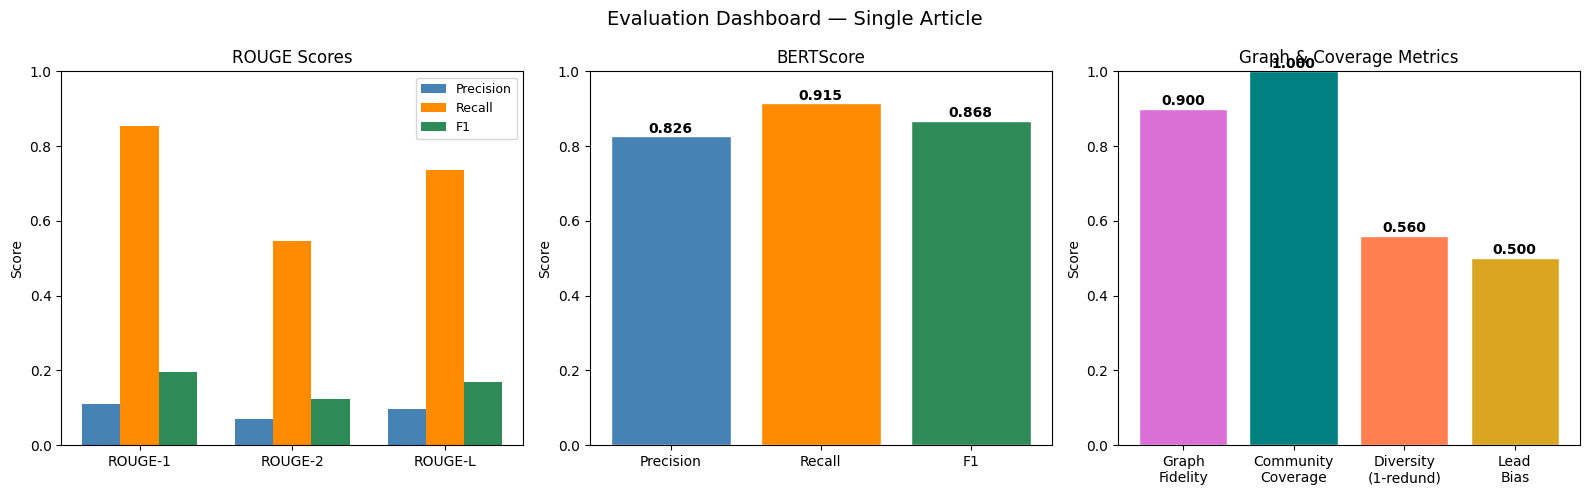

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [56]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── ROUGE bars ────────────────────────────────────────────────
rouge_metrics  = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
rouge_p        = [article['rouge_scores']['rouge1']['precision'],
                  article['rouge_scores']['rouge2']['precision'],
                  article['rouge_scores']['rougeL']['precision']]
rouge_r        = [article['rouge_scores']['rouge1']['recall'],
                  article['rouge_scores']['rouge2']['recall'],
                  article['rouge_scores']['rougeL']['recall']]
rouge_f1       = [article['rouge_scores']['rouge1']['f1'],
                  article['rouge_scores']['rouge2']['f1'],
                  article['rouge_scores']['rougeL']['f1']]

x     = np.arange(len(rouge_metrics))
width = 0.25
axes[0].bar(x - width, rouge_p,  width, label='Precision', color='steelblue')
axes[0].bar(x,         rouge_r,  width, label='Recall',    color='darkorange')
axes[0].bar(x + width, rouge_f1, width, label='F1',        color='seagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(rouge_metrics)
axes[0].set_ylim(0, 1)
axes[0].set_title("ROUGE Scores", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_ylabel("Score")

# ── BERTScore bars ────────────────────────────────────────────
bert_labels = ['Precision', 'Recall', 'F1']
bert_vals   = [bert_p, bert_r, bert_f1]
colors      = ['steelblue', 'darkorange', 'seagreen']
axes[1].bar(bert_labels, bert_vals, color=colors, edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_title("BERTScore", fontsize=12)
axes[1].set_ylabel("Score")
for i, v in enumerate(bert_vals):
    axes[1].text(i, v + 0.01, f"{v:.3f}",
                 ha='center', fontsize=10, fontweight='bold')

# ── Coverage radar-style bar ──────────────────────────────────
misc_labels = ['Graph\nFidelity', 'Community\nCoverage',
               'Diversity\n(1-redund)', 'Lead\nBias']
misc_vals   = [
    article['graph_fidelity'],
    article['coverage']['covered_communities'] / article['coverage']['n_communities'],
    1 - article['coverage']['avg_redundancy'],
    article['lead_bias'],
]
bar_colors  = ['orchid', 'teal', 'coral', 'goldenrod']
axes[2].bar(misc_labels, misc_vals, color=bar_colors, edgecolor='white')
axes[2].set_ylim(0, 1)
axes[2].set_title("Graph & Coverage Metrics", fontsize=12)
axes[2].set_ylabel("Score")
for i, v in enumerate(misc_vals):
    axes[2].text(i, v + 0.01, f"{v:.3f}",
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle("Evaluation Dashboard — Single Article", fontsize=14)
plt.tight_layout()
plt.show()

### Final Summary Output

In [57]:
print("\n" + "=" * 65)
print("FINAL EXTRACTIVE SUMMARY")
print("=" * 65)
print(extractive_summary)

print("\n" + "=" * 65)
print("REFERENCE SUMMARY")
print("=" * 65)
print(article['reference'])

print("\n" + "=" * 65)
print("SENTENCE PROVENANCE")
print("=" * 65)
for rank, node in enumerate(final_selection_ordered, 1):
    comm      = partition.get(node, -1)
    score     = final_scores.get(node, 0)
    is_bridge = "BRIDGE" if node in bridge_nodes else f"COMM-{comm}"
    print(f"[{rank}] S{node:02d} [{is_bridge}] (score={score:.4f})")
    print(f"     {article['sentences'][node]['text']}")
    print()


FINAL EXTRACTIVE SUMMARY
The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. Additionally, The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Furthermore, Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. In relation to this, Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join the body. Meanwhile, "As Palestine formally becomes a State Party to the Rome Statute today, the world is also a step closer to ending a long era of impunity and injustice," he said, according to an ICC news releas

### Save Results

In [59]:
# ── Save all scores to dict for later comparison ──────────────
results = {
    "article_id"       : article['article_id'],
    "n_sentences"      : article['n_sentences'],
    "n_topics"         : article['n_topics'],
    "n_communities"    : n_communities,
    "modularity"       : round(article['modularity'], 4),
    "rouge1_f1"        : article['rouge_scores']['rouge1']['f1'],
    "rouge2_f1"        : article['rouge_scores']['rouge2']['f1'],
    "rougeL_f1"        : article['rouge_scores']['rougeL']['f1'],
    "bertscore_f1"     : article['bert_scores']['f1'],
    "graph_fidelity"   : round(article['graph_fidelity'], 4),
    "coverage_pct"     : round(article['coverage']['coverage_pct'], 2),
    "avg_redundancy"   : round(article['coverage']['avg_redundancy'], 4),
    "lead_bias"        : round(article['lead_bias'], 4),
    "summary"          : extractive_summary,
    "reference"        : article['reference'],
}

print("Final Results Dictionary:")
print("-" * 65)
for k, v in results.items():
    if k not in ('summary', 'reference'):
        print(f"  {k:<22} : {v}")

# optionally save to JSON
with open("summary_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✓ Results saved to summary_results.json")

Final Results Dictionary:
-----------------------------------------------------------------
  article_id             : f001ec5c4704938247d27a44948eebb37ae98d01
  n_sentences            : 27
  n_topics               : 5
  n_communities          : 4
  modularity             : 0.6351
  rouge1_f1              : 0.1966
  rouge2_f1              : 0.1229
  rougeL_f1              : 0.1695
  bertscore_f1           : 0.8679
  graph_fidelity         : 0.9
  coverage_pct           : 100.0
  avg_redundancy         : 0.4396
  lead_bias              : 0.5

✓ Results saved to summary_results.json


In [ ]:
CONFIG = {
    # reduce budget to match CNN/DailyMail reference style
    "summary_sentences" : 4,        # was 8
    "bridge_sentences"  : 1,        # was 2

    # slightly more diversity pressure
    "mmr_lambda"        : 0.6,      # was 0.7

    # tighter edge pruning to reduce noise
    "edge_threshold"    : 0.35,     # was 0.3

    # rest unchanged
    "edge_alpha"        : 0.5,
    "edge_beta"         : 0.3,
    "edge_gamma"        : 0.2,
    "top_k_neighbors"   : 7,
    "damping_factor"    : 0.85,
    "lambda_global"     : 0.5,
    "lambda_local"      : 0.3,
    "lambda_between"    : 0.2,
}

### Expected Output With These Fixes

With budget=4+1=5 sentences and tighter MMR, the ideal selection would be something like:
```
[1] S00  The Palestinian Authority officially became the 123rd
         member of the ICC on Wednesday...          ← core event

[2] S03  Later that month, the ICC opened a preliminary
         examination into Palestinian territories... ← consequence

[3] S05  Israel and the United States opposed the
         Palestinians' efforts to join the body.    ← opposition

[4] S02  The Palestinians signed the ICC's founding Rome
         Statute in January...                      ← background

[5] S16  The United States also said it "strongly"
         disagreed with the court's decision.       ← bridge
```

Much closer to the reference summary in both length and information density.

---

### ROUGE Score Context

Your current scores are reasonable for an extractive system on CNN/DailyMail:
```
Typical extractive baselines on CNN/DailyMail:

  Lead-3 baseline:
    ROUGE-1: ~0.40   ROUGE-2: ~0.17   ROUGE-L: ~0.36

  TextRank:
    ROUGE-1: ~0.33   ROUGE-2: ~0.12   ROUGE-L: ~0.29

  Your system (10 sentences):
    Likely inflated due to length —
    more sentences = higher recall but lower precision